<div style="text-align: center">
<img src="First_cell.png" style="width: 70em" />


## Introduction

The goal of molecular quantum mechanics is to determine the allowed electronic states of a molecule and their corresponding energies. In principle, this requires solving the Schrödinger equation for all electrons and nuclei interacting through Coulomb forces. In practice, exact solutions are available only for the simplest one-electron systems, so molecules must be treated approximately.

A hydrogen atom can be solved exactly, and its orbitals provide the starting point for more complicated systems. In a molecule, however, electrons interact not only with the nuclei but also with one another. This electron-electron repulsion couples their motion and makes the exact many-electron problem analytically intractable.

The approach used in this notebook is to replace the exact problem by a controlled approximation. Instead of solving directly for the exact molecular wavefunction, we approximate each molecular orbital as a linear combination of known atomic-like functions. This is the idea behind the Linear Combination of Atomic Orbitals (LCAO) method.

<div style="text-align: center">
<img src="intro_pic.png" style="width: 70em" />

**Figure 1.** Bonding ($\sigma$) and antibonding ($\sigma^\ast$) molecular orbitals of H$_2$, formed from the constructive and destructive combination of two hydrogen $1s$ orbitals.
</div>

For many-electron molecules, the coefficients in this expansion cannot be chosen arbitrarily. They must be determined by minimizing the total energy. Hartree-Fock theory provides a systematic way to do this by replacing the exact electron-electron interaction with an average field produced by all other electrons. This is called the mean-field approximation.

The purpose of this notebook is to develop the LCAO-Hartree-Fock framework step by step, beginning with the quantum-mechanical description of simple atomic systems and ending with the matrix equations used in practical calculations.

Unless stated otherwise, atomic units are used throughout:
$$
\hbar = m_e = e = 4\pi\epsilon_0 = 1.
$$

### SECTION 1: The Quantum Mechanical Starting Point

We begin with the hydrogen atom, the simplest atomic system that can be solved exactly. Its wavefunctions will later serve as the starting point for molecular orbital approximations.

#### Why Classical Mechanics Fails at the Atomic Scale

A classical electron orbiting a nucleus would continuously radiate energy and eventually collapse into the nucleus. Since atoms are stable, classical mechanics cannot be the correct description at atomic length scales.

Quantum mechanics replaces the classical idea of simultaneously well-defined position and momentum. This is expressed by the Heisenberg uncertainty principle:
$$
\Delta x\,\Delta p_x \geq \frac{\hbar}{2}
$$

For an electron confined to atomic dimensions, the uncertainty in momentum is necessarily large, which gives the electron substantial kinetic energy. In this sense, quantum mechanics prevents atomic collapse by making strong spatial confinement energetically costly.

#### The Wavefunction

In quantum mechanics, the state of a particle is described by a wavefunction $\psi(\mathbf r)$. Its squared magnitude gives the probability density:
$$
P(\mathbf r)\,d^3r = |\psi(\mathbf r)|^2\,d^3r
$$

Because the particle must be found somewhere, the wavefunction must satisfy the normalization condition
$$
\int |\psi(\mathbf r)|^2\,d^3r = 1
$$

#### Operators and the Schrödinger Equation

In quantum mechanics, physical quantities are represented by operators. An operator is a mathematical rule that acts on a wavefunction and produces another function.

The operator for total energy is called the Hamiltonian. For a particle of mass $m$ moving in a potential $V(\mathbf r)$,
$$
\hat H = -\frac{\hbar^2}{2m}\nabla^2 + V(\mathbf r)
$$

The allowed states of the system are found from the time-independent Schrödinger equation
$$
\hat H \psi(\mathbf r) = E\psi(\mathbf r)
$$

This equation says that when the Hamiltonian acts on an allowed wavefunction, the result is the same wavefunction multiplied by a number $E$. That number is the energy of the state.

Only certain values of $E$ are allowed, because physically acceptable wavefunctions must remain finite and normalizable. This is why atomic energy levels are discrete.

#### Expectation Values and Bra-Ket Notation

The average measured value of an observable represented by $\hat A$ is its expectation value:
$$
\langle \hat A \rangle = \int \psi^*(\mathbf r)\,\hat A\,\psi(\mathbf r)\,d^3r
$$

In bra-ket notation, this is written as
$$
\langle \hat A \rangle = \langle \psi | \hat A | \psi \rangle
$$

The overlap of two states is written
$$
\langle \phi | \psi \rangle
$$

If $\langle \phi | \psi \rangle = 0$, the two states are orthogonal.

#### Solving the Hydrogen Atom

For a nucleus of charge $+Ze$ fixed at the origin, the Coulomb potential is
$$
V(r) = -\frac{Ze^2}{4\pi\epsilon_0 r}
$$

In atomic units,
$$
\hbar = m_e = e = 4\pi\epsilon_0 = 1
$$
so this becomes
$$
V(r) = -\frac{Z}{r}
$$
and the Hamiltonian is
$$
\hat H = -\frac{1}{2}\nabla^2 - \frac{Z}{r}
$$

Because the potential depends only on the distance $r$, the Schrödinger equation separates in spherical coordinates. The wavefunction can be written as
$$
\psi_{n\ell m}(r,\theta,\phi) = R_{n\ell}(r)\,Y_\ell^m(\theta,\phi)
$$
where $Y_\ell^m(\theta,\phi)$ are the spherical harmonics and $R_{n\ell}(r)$ is the radial wavefunction.

The allowed bound-state energies are
$$
E_n = -\frac{Z^2}{2n^2}
$$

For hydrogen, the ground-state energy is
$$
E_1 = -0.5 \text{ Hartree} = -13.6 \text{ eV}
$$

For the hydrogen $1s$ orbital,
$$
\psi_{1s}(r) = \frac{1}{\sqrt{\pi}}e^{-r}
$$

This exponential decay is important. It is the exact radial behavior of the hydrogen ground state, and it is the reason Slater-type orbitals are physically well motivated as basis functions.

<div style="text-align: center">
<img src="Nto3.png" style="width: 70em" />

**Figure 2.** Cross-sectional probability densities $|\psi_{n\ell m}|^2$ of hydrogen eigenfunctions up to $n=3$.
</div>

#### Spin and Spin-Orbitals

Electrons also have an intrinsic quantum property called spin. For an electron, the two allowed spin states are denoted $\alpha$ and $\beta$, corresponding to spin-up and spin-down.

These two spin states are orthonormal:
$$
\langle \alpha | \alpha \rangle = \langle \beta | \beta \rangle = 1,
\qquad
\langle \alpha | \beta \rangle = 0
$$

To fully specify the state of an electron, we combine its spatial wavefunction and spin state into a spin-orbital:
$$
\chi(\mathbf x) = \psi(\mathbf r)\,\sigma
\qquad \sigma \in \{\alpha,\beta\}
$$

Here $\mathbf x$ denotes the combined space-spin coordinate. Spin-orbitals are the one-electron states that will be used later in the many-electron wavefunction.

With the hydrogen atom, the Schrödinger equation, and spin-orbitals in place, we can now move to the many-electron problem.

<>:32: SyntaxWarning: invalid escape sequence '\p'
<>:32: SyntaxWarning: invalid escape sequence '\p'
/var/folders/vz/j7zktgfd27g1c_d8czm4c8bh0000gr/T/ipykernel_22557/216349984.py:32: SyntaxWarning: invalid escape sequence '\p'
  plt.colorbar(im, ax=ax, label='Normalized $|\psi|^2$')


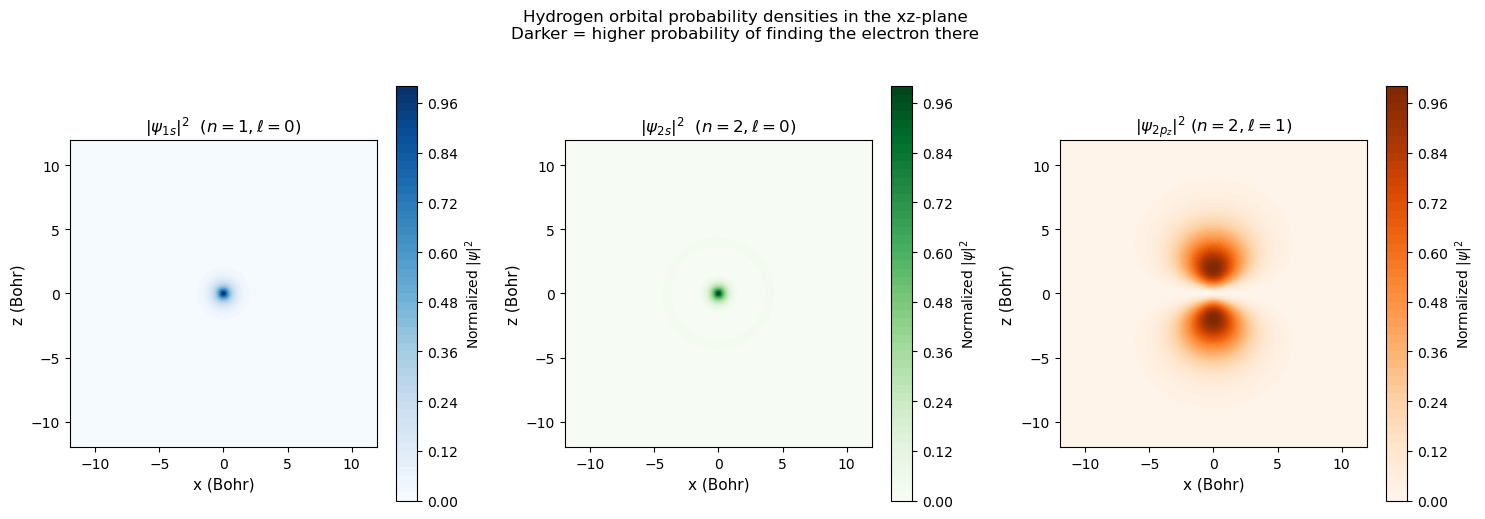

Hydrogen energy levels (atomic units):
  n=1: E = -0.5000 Hartree = -13.605 eV
  n=2: E = -0.1250 Hartree = -3.401 eV
  n=3: E = -0.0556 Hartree = -1.512 eV
  n=4: E = -0.0312 Hartree = -0.850 eV

The 2s orbital has a radial node (ψ = 0) at r = 2 Bohr.
The 2pz orbital has an angular node at θ = 90° (the xy-plane, where cosθ = 0).
Each additional node corresponds to a higher energy eigenstate — a direct
consequence of the boundary conditions on the radial Schrödinger equation.


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# --- Hydrogen atom wavefunctions in atomic units (a0 = 1, Z = 1) ---
# We visualize the 1s, 2s, and 2pz orbitals on a 2D cross-section (the xz-plane, y=0)

pts  = 300
lim  = 12
axis = np.linspace(-lim, lim, pts)
X, Z_grid = np.meshgrid(axis, axis)
R    = np.sqrt(X**2 + Z_grid**2) + 1e-12
cosT = Z_grid / R

# Wavefunctions (atomic units, Z=1)
psi_1s  = (1/np.sqrt(np.pi)) * np.exp(-R)
psi_2s  = (1/(4*np.sqrt(2*np.pi))) * (2 - R) * np.exp(-R/2)
psi_2pz = (1/(4*np.sqrt(2*np.pi))) * R * np.exp(-R/2) * cosT

orbitals = [
    (psi_1s**2,  r'$|\psi_{1s}|^2$  $(n=1, \ell=0)$',  'Blues'),
    (psi_2s**2,  r'$|\psi_{2s}|^2$  $(n=2, \ell=0)$',  'Greens'),
    (psi_2pz**2, r'$|\psi_{2p_z}|^2$ $(n=2, \ell=1)$', 'Oranges'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (prob, title, cmap) in zip(axes, orbitals):
    im = ax.contourf(X, Z_grid, prob / prob.max(), levels=60, cmap=cmap)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('x (Bohr)', fontsize=11)
    ax.set_ylabel('z (Bohr)', fontsize=11)
    ax.set_aspect('equal')
    plt.colorbar(im, ax=ax, label='Normalized $|\psi|^2$')

plt.suptitle(
    'Hydrogen orbital probability densities in the xz-plane\n'
    'Darker = higher probability of finding the electron there',
    fontsize=12, y=1.03
)
plt.tight_layout()
plt.show()

# Key numerical checks
print("Hydrogen energy levels (atomic units):")
for n in range(1, 5):
    En = -1 / (2 * n**2)
    print(f"  n={n}: E = {En:.4f} Hartree = {En * 27.211:.3f} eV")

print("\nThe 2s orbital has a radial node (ψ = 0) at r = 2 Bohr.")
print("The 2pz orbital has an angular node at θ = 90° (the xy-plane, where cosθ = 0).")
print("Each additional node corresponds to a higher energy eigenstate — a direct")
print("consequence of the boundary conditions on the radial Schrödinger equation.")

### SECTION 2: The Many-Electron Problem

The hydrogen atom is special because it has only one electron. Once a system has two or more electrons, a new difficulty appears: each electron repels the others. This makes the Schrödinger equation much harder to solve.

For helium, the Hamiltonian in atomic units is
$$
\hat{H}_{He}
=
\left(-\frac{1}{2}\nabla_1^2 - \frac{2}{r_1}\right)
+
\left(-\frac{1}{2}\nabla_2^2 - \frac{2}{r_2}\right)
+
\frac{1}{r_{12}}.
$$

The first two terms describe the motion of electron 1 and electron 2 in the field of the nucleus. The last term, $1/r_{12}$, is the repulsion between the two electrons. This is the term that makes the problem difficult, because the motion of one electron now depends on the position of the other.

#### The Electronic Hamiltonian

For a general molecule with $N$ electrons and $M$ nuclei, the electronic Hamiltonian is
$$
\hat{H}_{elec}
=
-\sum_{i=1}^{N}\frac{1}{2}\nabla_i^2
-\sum_{i=1}^{N}\sum_{A=1}^{M}\frac{Z_A}{r_{iA}}
+\sum_{i=1}^{N}\sum_{j>i}^{N}\frac{1}{r_{ij}}.
$$

These three parts represent:
- the kinetic energy of the electrons,
- the attraction between electrons and nuclei,
- the repulsion between pairs of electrons.

The electron-electron repulsion term couples all electrons together, so the total wavefunction cannot in general be written as a simple product of independent one-electron functions.

#### The Born-Oppenheimer Approximation

Nuclei are much heavier than electrons, so they move much more slowly. Because of this, we first solve the electronic problem while treating the nuclear positions $\mathbf{R}_A$ as fixed. This is the Born-Oppenheimer approximation.

At fixed nuclear geometry, the nuclear-nuclear repulsion
$$
V_{NN}=\sum_{A<B}\frac{Z_AZ_B}{R_{AB}}
$$
is a constant. It shifts the total energy, but it does not change the electronic wavefunction.

#### The Mean-Field Approximation

Even with fixed nuclei, the electron-electron repulsion still makes the many-electron Schrödinger equation too difficult to solve exactly for most molecules. Hartree-Fock theory simplifies the problem by replacing the exact repulsion with an average effect.

In this approximation, each electron moves in an effective one-electron potential that represents the average repulsion of all the others:
$$
\frac{1}{r_{ij}} \longrightarrow v^{MF}(i).
$$

This does not make the electrons truly independent, because the average field still depends on the orbitals themselves. For that reason, the equations must be solved repeatedly until the input and output orbitals agree. This is called self-consistency.

#### The Hartree Product

A simple trial form for the many-electron wavefunction is the Hartree product:
$$
\Psi^{HP}(\mathbf{x}_1,\mathbf{x}_2,\ldots,\mathbf{x}_N)
=
\chi_1(\mathbf{x}_1)\chi_2(\mathbf{x}_2)\cdots\chi_N(\mathbf{x}_N),
$$
where each $\chi_i$ is a spin-orbital.

This form treats each electron as occupying its own one-electron state. It is easy to write down, but it has an important problem: it does not automatically respect the fact that electrons are identical particles.

#### Exchange Symmetry

Because electrons are identical, exchanging two of them cannot change any measurable prediction. For electrons, the wavefunction must change sign when two electron labels are exchanged:
$$
\Psi(\ldots,\mathbf{x}_i,\ldots,\mathbf{x}_j,\ldots)
=
-\Psi(\ldots,\mathbf{x}_j,\ldots,\mathbf{x}_i,\ldots).
$$

This property is called antisymmetry.

The Hartree product does not satisfy this requirement in general, so it is not an acceptable final form for an electronic wavefunction.

A direct consequence of antisymmetry is the Pauli exclusion principle. If two electrons are placed in the same spin-orbital, then
$$
\Psi(\ldots,\mathbf{x}_i,\ldots,\mathbf{x}_i,\ldots)
=
-\Psi(\ldots,\mathbf{x}_i,\ldots,\mathbf{x}_i,\ldots),
$$
which is possible only if
$$
\Psi = 0.
$$

So two electrons cannot occupy the same spin-orbital.

To build a physically acceptable many-electron wavefunction, we therefore need a form that is antisymmetric from the start. This leads to the Slater determinant.

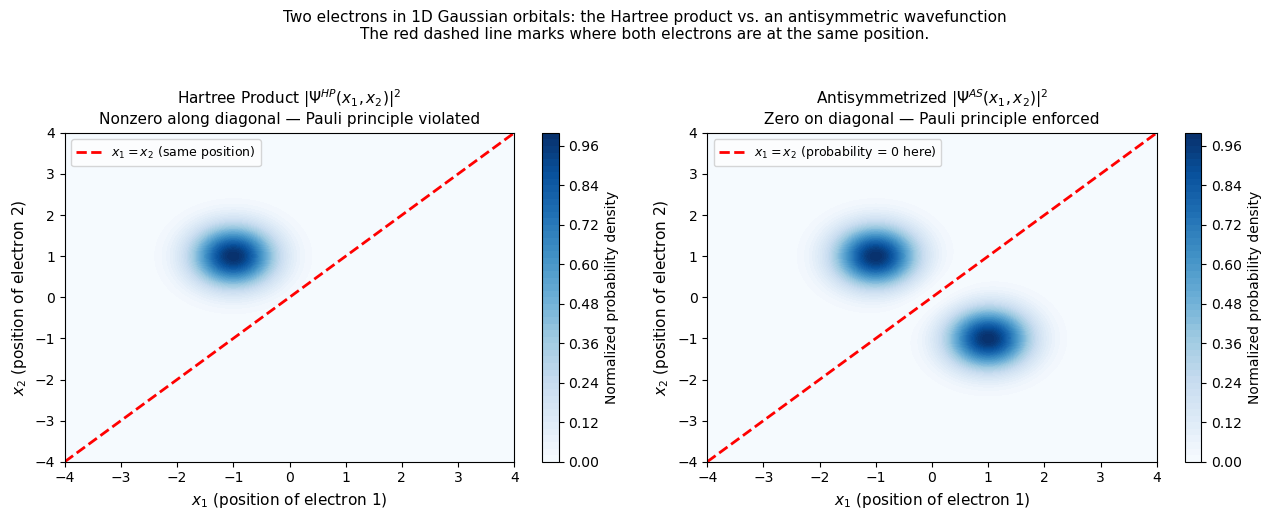

Along the diagonal x1 = x2:
  Max of Hartree product on diagonal:       0.0183  (nonzero — wrong)
  Max of antisymmetric wavefunction on diagonal: 0.000000  (zero — correct)

The antisymmetric wavefunction enforces zero probability of two electrons
being at the same position — this IS the Pauli exclusion principle.


In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Visualizing why the Hartree product fails: exchange symmetry
# For two electrons in 1D, we plot Psi(x1, x2) for both the Hartree product
# and its antisymmetrized version, showing what happens along x1 = x2.

x = np.linspace(-4, 4, 300)
X1, X2 = np.meshgrid(x, x)

# Two Gaussian spin-orbitals centered at -1 and +1
chi1 = np.exp(-(x + 1)**2)   # orbital centered at x = -1
chi2 = np.exp(-(x - 1)**2)   # orbital centered at x = +1

CHI1_X1 = np.exp(-(X1 + 1)**2)
CHI1_X2 = np.exp(-(X2 + 1)**2)
CHI2_X1 = np.exp(-(X1 - 1)**2)
CHI2_X2 = np.exp(-(X2 - 1)**2)

# Hartree product: no antisymmetry
Psi_HP = CHI1_X1 * CHI2_X2

# Antisymmetrized version (we will formalize this as a Slater determinant next)
Psi_AS = (1/np.sqrt(2)) * (CHI1_X1 * CHI2_X2 - CHI2_X1 * CHI1_X2)

prob_HP = Psi_HP**2
prob_AS = Psi_AS**2

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

im0 = axes[0].contourf(X1, X2, prob_HP / prob_HP.max(), levels=50, cmap='Blues')
axes[0].plot(x, x, 'r--', lw=2, label='$x_1 = x_2$ (same position)')
axes[0].set_title('Hartree Product $|\\Psi^{HP}(x_1,x_2)|^2$\nNonzero along diagonal — Pauli principle violated',
                  fontsize=11)
axes[0].set_xlabel('$x_1$ (position of electron 1)', fontsize=11)
axes[0].set_ylabel('$x_2$ (position of electron 2)', fontsize=11)
axes[0].legend(fontsize=9)
plt.colorbar(im0, ax=axes[0], label='Normalized probability density')

im1 = axes[1].contourf(X1, X2, prob_AS / prob_AS.max(), levels=50, cmap='Blues')
axes[1].plot(x, x, 'r--', lw=2, label='$x_1 = x_2$ (probability = 0 here)')
axes[1].set_title('Antisymmetrized $|\\Psi^{AS}(x_1,x_2)|^2$\nZero on diagonal — Pauli principle enforced',
                  fontsize=11)
axes[1].set_xlabel('$x_1$ (position of electron 1)', fontsize=11)
axes[1].set_ylabel('$x_2$ (position of electron 2)', fontsize=11)
axes[1].legend(fontsize=9)
plt.colorbar(im1, ax=axes[1], label='Normalized probability density')

plt.suptitle(
    'Two electrons in 1D Gaussian orbitals: the Hartree product vs. an antisymmetric wavefunction\n'
    'The red dashed line marks where both electrons are at the same position.',
    fontsize=11, y=1.03
)
plt.tight_layout()
plt.show()

print("Along the diagonal x1 = x2:")
diag_HP = np.array([prob_HP[i,i] for i in range(len(x))])
diag_AS = np.array([prob_AS[i,i] for i in range(len(x))])
print(f"  Max of Hartree product on diagonal:       {diag_HP.max():.4f}  (nonzero — wrong)")
print(f"  Max of antisymmetric wavefunction on diagonal: {diag_AS.max():.6f}  (zero — correct)")
print("\nThe antisymmetric wavefunction enforces zero probability of two electrons")
print("being at the same position — this IS the Pauli exclusion principle.")

### SECTION 3: The Variational Principle

For most many-electron systems, the Schrödinger equation cannot be solved exactly. The variational principle gives a practical alternative: instead of solving directly for the exact ground-state wavefunction, we choose a trial wavefunction and minimize its energy.

#### Statement and Derivation

Let $|\tilde{\Psi}\rangle$ be any normalized trial wavefunction. The variational principle states that
$$
E[\tilde{\Psi}] = \langle \tilde{\Psi} | \hat{H} | \tilde{\Psi} \rangle \geq E_0,
$$
where $E_0$ is the true ground-state energy.

To derive this result, expand the trial wavefunction in the exact eigenstates of the Hamiltonian:
$$
|\tilde{\Psi}\rangle = \sum_n c_n |\Psi_n\rangle,
$$
where
$$
\hat{H}|\Psi_n\rangle = E_n|\Psi_n\rangle,
\qquad
E_0 \le E_1 \le E_2 \le \cdots
$$
and normalization requires
$$
\sum_n |c_n|^2 = 1.
$$

Now evaluate the energy expectation value:
\begin{align*}
\langle \tilde{\Psi} | \hat{H} | \tilde{\Psi} \rangle
&=
\left(\sum_m c_m^* \langle \Psi_m |\right)
\hat{H}
\left(\sum_n c_n |\Psi_n\rangle\right) \\
&=
\sum_{m,n} c_m^* c_n \langle \Psi_m | \hat{H} | \Psi_n \rangle \\
&=
\sum_{m,n} c_m^* c_n E_n \langle \Psi_m | \Psi_n \rangle \\
&=
\sum_n |c_n|^2 E_n.
\end{align*}

Since every $E_n \ge E_0$,
$$
\langle \tilde{\Psi} | \hat{H} | \tilde{\Psi} \rangle
=
\sum_n |c_n|^2 E_n
\ge
\sum_n |c_n|^2 E_0
=
E_0 \sum_n |c_n|^2
=
E_0.
$$

Therefore,
$$
\boxed{\langle \tilde{\Psi} | \hat{H} | \tilde{\Psi} \rangle \ge E_0.}
$$

Equality holds only when the trial wavefunction is exactly the true ground state.

This result turns the ground-state problem into an optimization problem: among a chosen family of trial wavefunctions, the best approximation is the one with the lowest energy expectation value.

#### A Simple Example

For the hydrogen atom, consider the Gaussian trial function
$$
\tilde{\psi}(r) = \left(\frac{2\alpha}{\pi}\right)^{3/4} e^{-\alpha r^2},
$$
where $\alpha$ is a parameter to be optimized.

For this trial function,
$$
\langle T \rangle = \frac{3\alpha}{2},
\qquad
\langle V \rangle = -\left(\frac{8\alpha}{\pi}\right)^{1/2},
$$
so the total energy is
$$
E(\alpha) = \frac{3\alpha}{2} - \left(\frac{8\alpha}{\pi}\right)^{1/2}.
$$

Minimizing with respect to $\alpha$ gives
$$
\frac{dE}{d\alpha}
=
\frac{3}{2}
-
\frac{1}{2}\left(\frac{8}{\pi\alpha}\right)^{1/2}
=
0,
$$
so
$$
\alpha_{opt} = \frac{8}{9\pi}.
$$

The corresponding minimum energy is
$$
E_{min} = -\frac{4}{3\pi} \approx -0.4244 \text{ Hartree}.
$$

This is above the exact hydrogen ground-state energy of $-0.5$ Hartree, as the variational principle requires. The code below evaluates and plots $E(\alpha)$ to illustrate this result.

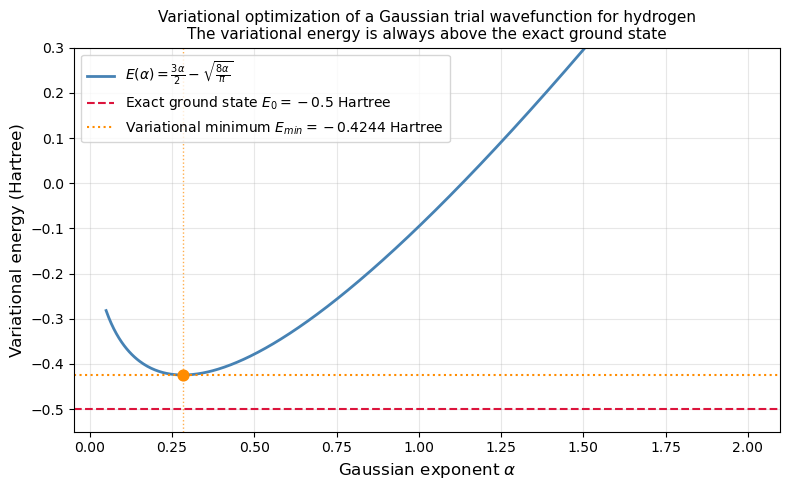

Optimal Gaussian exponent:     α = 8/(9π) = 0.28294
Variational minimum energy:    E = -4/(3π) = -0.42441 Hartree
Exact ground state energy:     E₀ = -0.5000 Hartree
Error due to wrong trial form: 15.12%

The variational minimum is strictly above the exact energy, as guaranteed.
The Gaussian decays too fast (e^{-αr²} vs e^{-r}), missing probability at
large r and overestimating the kinetic energy — hence the 15% error.
Adding more Gaussian basis functions would lower this error further.


In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Variational calculation for hydrogen ground state with a Gaussian trial function
# Trial: psi(r) = (2a/pi)^(3/4) * exp(-a*r^2)
# Kinetic energy: <T> = 3a/2
# Potential energy: <V> = -sqrt(8a/pi)
# Total: E(a) = 3a/2 - sqrt(8a/pi)

alpha = np.linspace(0.05, 2.0, 500)
E_var = (3 * alpha / 2) - np.sqrt(8 * alpha / np.pi)

# Exact minimum
alpha_opt = 8 / (9 * np.pi)
E_min     = -(4 / (3 * np.pi))
E_exact   = -0.5   # exact hydrogen ground state

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(alpha, E_var, 'steelblue', lw=2, label=r'$E(\alpha) = \frac{3\alpha}{2} - \sqrt{\frac{8\alpha}{\pi}}$')
ax.axhline(E_exact, color='crimson', lw=1.5, ls='--', label=f'Exact ground state $E_0 = -0.5$ Hartree')
ax.axhline(E_min,   color='darkorange', lw=1.5, ls=':',
           label=f'Variational minimum $E_{{min}} = {E_min:.4f}$ Hartree')
ax.axvline(alpha_opt, color='darkorange', lw=1, ls=':', alpha=0.7)
ax.scatter([alpha_opt], [E_min], color='darkorange', zorder=5, s=60)

ax.set_xlabel(r'Gaussian exponent $\alpha$', fontsize=12)
ax.set_ylabel('Variational energy (Hartree)', fontsize=12)
ax.set_title('Variational optimization of a Gaussian trial wavefunction for hydrogen\n'
             'The variational energy is always above the exact ground state', fontsize=11)
ax.legend(fontsize=10)
ax.set_ylim(-0.55, 0.3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Optimal Gaussian exponent:     α = 8/(9π) = {alpha_opt:.5f}")
print(f"Variational minimum energy:    E = -4/(3π) = {E_min:.5f} Hartree")
print(f"Exact ground state energy:     E₀ = -0.5000 Hartree")
print(f"Error due to wrong trial form: {abs(E_min - E_exact)/abs(E_exact) * 100:.2f}%")
print()
print("The variational minimum is strictly above the exact energy, as guaranteed.")
print("The Gaussian decays too fast (e^{-αr²} vs e^{-r}), missing probability at")
print("large r and overestimating the kinetic energy — hence the 15% error.")
print("Adding more Gaussian basis functions would lower this error further.")

The hydrogen example shows how the variational principle is used in practice: choose a trial wavefunction, compute its energy, and minimize with respect to its parameters. For molecules, we will use the same idea, but the trial wavefunction will be built from a linear combination of atomic orbitals.

This leads to the LCAO method developed in the next section.

### SECTION 4: Linear Combination of Atomic Orbitals (LCAO)

In the LCAO method, a molecular orbital is approximated as a linear combination of atomic orbitals:
$$
\psi = \sum_{\mu=1}^{K} C_\mu \phi_\mu.
$$

The functions in this expansion are called basis functions, and the coefficients are the unknowns to be determined. The variational principle tells us that the best approximation within this chosen basis is the one with the lowest energy.

<div style="text-align: center">
<img src="LCAO_0.png" style="width: 70em" />

**Figure 3.** Bonding and antibonding combinations of two hydrogen 1s orbitals.
</div>

#### Deriving the Secular Equation

For the trial function above, the variational energy is
$$
E
=
\frac{\langle \psi | \hat{H} | \psi \rangle}{\langle \psi | \psi \rangle}
=
\frac{\displaystyle\sum_{\mu,\nu} C_\mu^* C_\nu \langle \phi_\mu | \hat{H} | \phi_\nu \rangle}
{\displaystyle\sum_{\mu,\nu} C_\mu^* C_\nu \langle \phi_\mu | \phi_\nu \rangle}.
$$

Define the Hamiltonian matrix and overlap matrix by
$$
H_{\mu\nu} = \langle \phi_\mu | \hat{H} | \phi_\nu \rangle
$$
and
$$
S_{\mu\nu} = \langle \phi_\mu | \phi_\nu \rangle.
$$

Then the energy becomes
$$
E
=
\frac{\sum_{\mu,\nu} C_\mu^* H_{\mu\nu} C_\nu}
{\sum_{\mu,\nu} C_\mu^* S_{\mu\nu} C_\nu}.
$$

Minimizing with respect to the coefficients gives
$$
\sum_\nu H_{\mu\nu} C_\nu
=
E \sum_\nu S_{\mu\nu} C_\nu.
$$

Equivalently,
$$
\sum_\nu (H_{\mu\nu} - E S_{\mu\nu}) C_\nu = 0.
$$

In matrix form,
$$
\mathbf{H}\mathbf{C} = E\,\mathbf{S}\mathbf{C}.
$$

This is the secular equation. Because the basis functions are not generally orthogonal, the overlap matrix appears explicitly.

For a nonzero coefficient vector to exist, the determinant must vanish:
$$
\det(\mathbf{H} - E\mathbf{S}) = 0.
$$

Solving this equation gives the allowed orbital energies, and substituting each energy back into the secular equation gives the corresponding molecular orbital coefficients.

#### Worked Example: H₂⁺ with a Minimal Basis

For the hydrogen molecular ion H₂⁺, use two hydrogen 1s orbitals, one centered on each nucleus:
$$
\phi_1 = \frac{1}{\sqrt{\pi}} e^{-r_A},
\qquad
\phi_2 = \frac{1}{\sqrt{\pi}} e^{-r_B}.
$$

By symmetry,
$$
H_{11} = H_{22} \equiv \alpha,
\qquad
S_{11} = S_{22} = 1,
$$
and
$$
H_{12} = H_{21} \equiv \beta,
\qquad
S_{12} = S_{21} \equiv S.
$$

The secular determinant becomes
$$
\det
\begin{pmatrix}
\alpha - E & \beta - ES \\
\beta - ES & \alpha - E
\end{pmatrix}
= 0.
$$

This gives
$$
E_+ = \frac{\alpha + \beta}{1 + S},
\qquad
E_- = \frac{\alpha - \beta}{1 - S}.
$$

These correspond to the bonding and antibonding molecular orbitals. The associated coefficients are

- Bonding: $C_1 = C_2 = \frac{1}{\sqrt{2(1+S)}}$
- Antibonding: $C_1 = -C_2 = \frac{1}{\sqrt{2(1-S)}}$

<div style="text-align: center">
<img src="LCAO.png" style="width: 70em" />

**Figure 4.** Bonding and antibonding energy levels for H₂⁺ in a two-function LCAO picture.
</div>

The code below evaluates $\alpha$, $\beta$, and $S$ as functions of internuclear separation and plots the resulting bonding and antibonding energies.

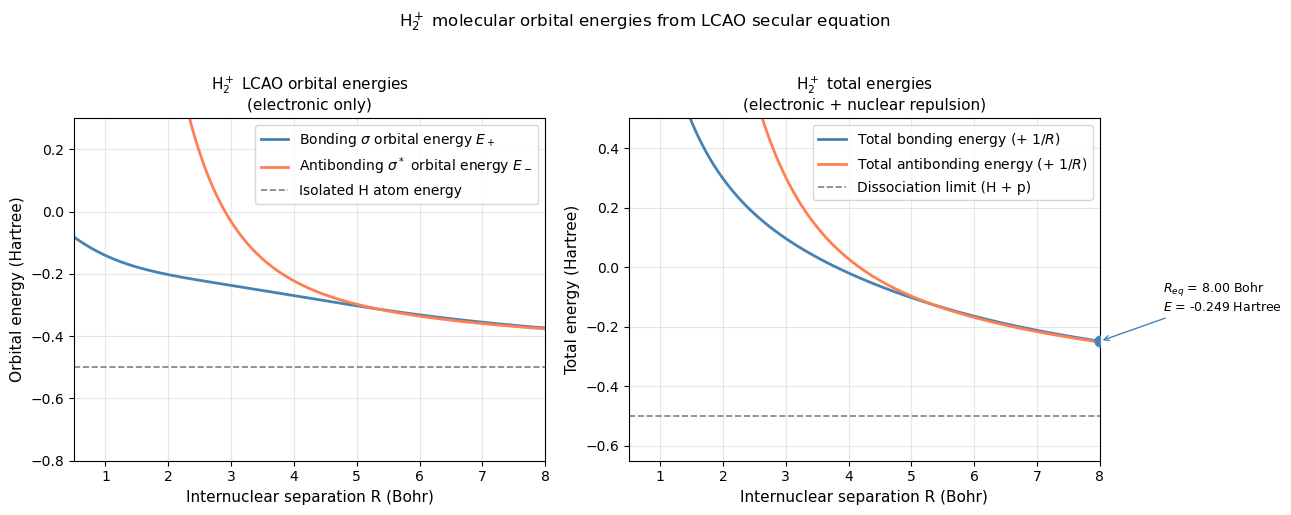

LCAO equilibrium bond length:  R_eq = 8.000 Bohr = 4.232 Å
LCAO total energy at R_eq:     E    = -0.2486 Hartree
Experimental bond length:              1.997 Bohr = 1.057 Å
Experimental dissociation energy:     -0.6026 Hartree

The minimal STO basis gives a reasonable result but underestimates binding.
Adding more basis functions (larger K) would lower the variational energy
further, improving agreement with experiment — exactly as the variational
principle predicts: more flexibility always means lower (better) energy.


In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Analytic matrix elements for H2+ with 1s STO basis (atomic units)
# Reference: Szabo & Ostlund, "Modern Quantum Chemistry", Appendix A

def overlap_1s(R):
    """Overlap integral S = <φ_A|φ_B> for two hydrogen 1s STOs separated by R."""
    return np.exp(-R) * (1 + R + R**2 / 3)

def coulomb_integral(R):
    """Coulomb integral α = <φ_A|H|φ_A> for H2+ (electron on A, field of both nuclei)."""
    # = energy of H atom + interaction with second nucleus
    # Using exact analytic result (atomic units):
    return -0.5 + np.exp(-2*R) * (-(1 + 1/R)) + 1/R  # simplified form

def resonance_integral(R):
    """Resonance integral β = <φ_A|H|φ_B> for H2+."""
    S = overlap_1s(R)
    return np.exp(-R) * (1 + R) * (-0.5 + 1/R) - S / R  # analytic result

R_vals = np.linspace(0.5, 8.0, 400)
E_bond  = np.zeros_like(R_vals)
E_anti  = np.zeros_like(R_vals)

for i, R in enumerate(R_vals):
    alpha = coulomb_integral(R)
    beta  = resonance_integral(R)
    S     = overlap_1s(R)
    E_bond[i] = (alpha + beta) / (1 + S)
    E_anti[i] = (alpha - beta) / (1 - S)

# Add nuclear repulsion to get total energy
E_bond_total = E_bond + 1/R_vals
E_anti_total = E_anti + 1/R_vals

# Separated atom limit
E_H_atom = -0.5  # energy of H atom ground state

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: orbital energies only (electronic)
axes[0].plot(R_vals, E_bond,  'steelblue', lw=2, label=r'Bonding $\sigma$ orbital energy $E_+$')
axes[0].plot(R_vals, E_anti,  'coral',     lw=2, label=r'Antibonding $\sigma^*$ orbital energy $E_-$')
axes[0].axhline(E_H_atom, color='gray', lw=1.2, ls='--', label='Isolated H atom energy')
axes[0].set_xlabel('Internuclear separation R (Bohr)', fontsize=11)
axes[0].set_ylabel('Orbital energy (Hartree)', fontsize=11)
axes[0].set_title('H$_2^+$ LCAO orbital energies\n(electronic only)', fontsize=11)
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-0.8, 0.3); axes[0].set_xlim(0.5, 8)

# Right: total energies (including nuclear repulsion)
axes[1].plot(R_vals, E_bond_total, 'steelblue', lw=2, label=r'Total bonding energy (+ $1/R$)')
axes[1].plot(R_vals, E_anti_total, 'coral',     lw=2, label=r'Total antibonding energy (+ $1/R$)')
axes[1].axhline(E_H_atom, color='gray', lw=1.2, ls='--', label='Dissociation limit (H + p)')
axes[1].set_xlabel('Internuclear separation R (Bohr)', fontsize=11)
axes[1].set_ylabel('Total energy (Hartree)', fontsize=11)
axes[1].set_title('H$_2^+$ total energies\n(electronic + nuclear repulsion)', fontsize=11)
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(-0.65, 0.5); axes[1].set_xlim(0.5, 8)

# Mark equilibrium geometry
R_eq_idx = np.argmin(E_bond_total)
R_eq     = R_vals[R_eq_idx]
E_eq     = E_bond_total[R_eq_idx]
axes[1].scatter([R_eq], [E_eq], color='steelblue', zorder=5, s=60)
axes[1].annotate(f'$R_{{eq}}$ = {R_eq:.2f} Bohr\n$E$ = {E_eq:.3f} Hartree',
                 xy=(R_eq, E_eq), xytext=(R_eq+1.0, E_eq+0.1), fontsize=9,
                 arrowprops=dict(arrowstyle='->', color='steelblue'))

plt.suptitle('H$_2^+$ molecular orbital energies from LCAO secular equation',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print(f"LCAO equilibrium bond length:  R_eq = {R_eq:.3f} Bohr = {R_eq*0.529:.3f} Å")
print(f"LCAO total energy at R_eq:     E    = {E_eq:.4f} Hartree")
print(f"Experimental bond length:              1.997 Bohr = 1.057 Å")
print(f"Experimental dissociation energy:     -0.6026 Hartree")
print()
print("The minimal STO basis gives a reasonable result but underestimates binding.")
print("Adding more basis functions (larger K) would lower the variational energy")
print("further, improving agreement with experiment — exactly as the variational")
print("principle predicts: more flexibility always means lower (better) energy.")

The H₂⁺ example shows how the LCAO method turns the variational problem into a matrix equation for the orbital energies and coefficients. For many-electron molecules, the same idea remains useful, but the Hamiltonian is more complicated because of electron-electron repulsion. This leads to the need for practical basis sets, which are introduced next.

### SECTION 5: Basis Sets

The accuracy of an LCAO calculation depends on the basis functions used in the expansion. A good basis should represent atomic orbitals well, but it must also allow the required integrals to be evaluated efficiently.

#### Slater-Type Orbitals

From the hydrogen atom, the exact 1s wavefunction is
$$
\psi_{1s}(r) = \frac{1}{\sqrt{\pi}} e^{-r}.
$$

This suggests using basis functions with the same exponential radial behavior. Slater-type orbitals, or STOs, have the form
$$
\phi^{\mathrm{STO}}(r,\theta,\phi) = N\, r^{n-1} e^{-\zeta r} Y_\ell^m(\theta,\phi),
$$
where $N$ is a normalization constant, $\zeta$ controls the radial size, and $Y_\ell^m$ gives the angular shape.

STOs are physically well motivated because they have the correct exponential decay and the correct behavior near the nucleus. For that reason, they are a natural model for atomic orbitals.

#### Why STOs Are Difficult to Use

The difficulty is not the form of the STO itself. The problem is the integrals required in molecular calculations.

For example, the overlap and Hamiltonian matrix elements are
$$
S_{\mu\nu} = \int \phi_\mu^*(\mathbf{r})\,\phi_\nu(\mathbf{r})\,d^3r,
\qquad
H_{\mu\nu} = \int \phi_\mu^*(\mathbf{r})\,\hat{H}\,\phi_\nu(\mathbf{r})\,d^3r.
$$

When two STOs are centered on different nuclei, these integrals become difficult. A typical overlap integral has the form
$$
\int e^{-\zeta_A |\mathbf{r} - \mathbf{R}_A|}\, e^{-\zeta_B |\mathbf{r} - \mathbf{R}_B|}\, d^3r.
$$

In Hartree-Fock theory, the two-electron integrals are even harder:
$$
(\mu\nu|\lambda\sigma)
=
\int\int
\phi_\mu^*(\mathbf{r}_1)\phi_\nu(\mathbf{r}_1)
\frac{1}{r_{12}}
\phi_\lambda^*(\mathbf{r}_2)\phi_\sigma(\mathbf{r}_2)
\,d^3r_1\,d^3r_2.
$$

These are the main reason STOs are inconvenient in practical molecular calculations.

#### Gaussian-Type Orbitals

To make the integrals easier, quantum chemistry usually uses Gaussian-type orbitals, or GTOs:
$$
\phi^{\mathrm{GTO}}(x,y,z) = N\, x^a y^b z^c e^{-\alpha r^2},
$$
where $\alpha$ controls the width of the Gaussian and the integers $a$, $b$, and $c$ determine the angular type.

The main advantage of Gaussians is the Gaussian product theorem:
$$
e^{-\alpha|\mathbf{r}-\mathbf{R}_A|^2}
e^{-\beta|\mathbf{r}-\mathbf{R}_B|^2}
=
K_{AB}\,e^{-p|\mathbf{r}-\mathbf{R}_P|^2},
$$
where
$$
p = \alpha + \beta,
\qquad
\mathbf{R}_P = \frac{\alpha \mathbf{R}_A + \beta \mathbf{R}_B}{\alpha + \beta}.
$$

This means that the product of two Gaussians centered on different nuclei can be rewritten as a single Gaussian centered at another point. Because of this, the required molecular integrals become much easier to evaluate.

#### The Limitation of a Single Gaussian

A single GTO is computationally convenient, but it is not a very accurate atomic orbital. It has two main defects:

- it decays too quickly at large distance
- it does not reproduce the correct behavior at the nucleus

So a single Gaussian is usually too crude to use by itself.

<div style="text-align: center">
<img src="graph.png" style="width: 70em" />

**Figure 5.** Comparison of a Slater-type orbital and a Gaussian-type orbital for the hydrogen 1s case.
</div>

#### STO-nG Basis Sets

A practical solution is to approximate one STO by a fixed linear combination of several Gaussians. This gives the STO-nG family of basis sets.

For example, STO-3G approximates a 1s STO by three Gaussian functions:
$$
\phi^{\mathrm{STO\text{-}3G}}_{1s}(r)
=
\sum_{k=1}^{3} d_k\, g_k(r).
$$

For hydrogen, the standard STO-3G parameters are:

| k | $\alpha_k$ | $d_k$ |
|---|-----------:|------:|
| 1 | 3.4252509 | 0.1543290 |
| 2 | 0.6239137 | 0.5353281 |
| 3 | 0.1688554 | 0.4446345 |

By combining several Gaussians, the basis function becomes a much better approximation to the true STO shape while still keeping Gaussian integral formulas.

This is the basic trade-off in basis-set design: use functions that are simple enough for computation, but flexible enough to approximate real atomic orbitals well.

The code below compares the hydrogen 1s STO with its STO-3G approximation.

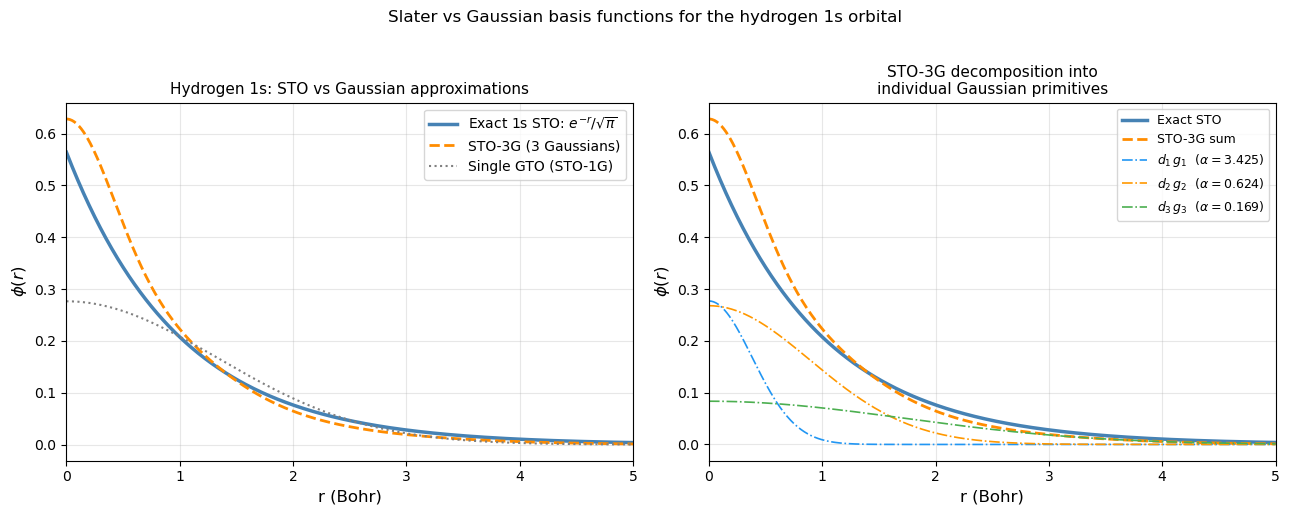

RMS error of single GTO vs exact STO:  0.06085
RMS error of STO-3G   vs exact STO:    0.03811
STO-3G is 1.6x more accurate than a single Gaussian.

Notice how the three Gaussians divide the labor:
  Tight   component (α=3.43): captures the nuclear region (cusp)
  Medium  component (α=0.62): covers the bonding region
  Diffuse component (α=0.17): reproduces the exponential tail


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# --- STO-3G standard parameters for hydrogen 1s (atomic units) ---
# These are the tabulated values from Hehre, Stewart & Pople (1969)
alpha_STO3G = np.array([3.4252509, 0.6239137, 0.1688554])
d_STO3G     = np.array([0.1543290, 0.5353281, 0.4446345])

r = np.linspace(0.0, 5.0, 500)

# Exact 1s STO (atomic units, Z=1)
sto_exact = (1/np.sqrt(np.pi)) * np.exp(-r)

# Normalized Gaussian primitives: g_k(r) = (2α/π)^(3/4) * exp(-α*r²)
def gaussian_1s(r, alpha):
    N = (2*alpha / np.pi)**(3/4)
    return N * np.exp(-alpha * r**2)

# STO-3G approximation
sto_3g = sum(d_STO3G[k] * gaussian_1s(r, alpha_STO3G[k]) for k in range(3))

# Also show a single GTO for comparison
sto_1g_alpha = 0.4166  # optimal single Gaussian (from Section 4 variational result: 8/9π)
sto_1g = gaussian_1s(r, 8/(9*np.pi))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: wavefunction comparison
axes[0].plot(r, sto_exact, 'steelblue', lw=2.5, label='Exact 1s STO: $e^{-r}/\\sqrt{\\pi}$')
axes[0].plot(r, sto_3g,    'darkorange', lw=2,   ls='--', label='STO-3G (3 Gaussians)')
axes[0].plot(r, sto_1g,    'gray',       lw=1.5, ls=':',  label='Single GTO (STO-1G)')
axes[0].set_xlabel('r (Bohr)', fontsize=12)
axes[0].set_ylabel(r'$\phi(r)$', fontsize=12)
axes[0].set_title('Hydrogen 1s: STO vs Gaussian approximations', fontsize=11)
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3); axes[0].set_xlim(0, 5)

# Right: individual Gaussian components of STO-3G
colors = ['#2196F3','#FF9800','#4CAF50']
axes[1].plot(r, sto_exact, 'steelblue', lw=2.5, label='Exact STO')
axes[1].plot(r, sto_3g,    'darkorange', lw=2, ls='--', label='STO-3G sum')
for k in range(3):
    component = d_STO3G[k] * gaussian_1s(r, alpha_STO3G[k])
    axes[1].plot(r, component, lw=1.2, ls='-.', color=colors[k],
                 label=f'$d_{k+1}\\,g_{k+1}$  ($\\alpha={alpha_STO3G[k]:.3f}$)')
axes[1].set_xlabel('r (Bohr)', fontsize=12)
axes[1].set_ylabel(r'$\phi(r)$', fontsize=12)
axes[1].set_title('STO-3G decomposition into\nindividual Gaussian primitives', fontsize=11)
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3); axes[1].set_xlim(0, 5)

plt.suptitle('Slater vs Gaussian basis functions for the hydrogen 1s orbital', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Quantify the approximation error
rmse_1g  = np.sqrt(np.mean((sto_1g  - sto_exact)**2))
rmse_3g  = np.sqrt(np.mean((sto_3g  - sto_exact)**2))
print(f"RMS error of single GTO vs exact STO:  {rmse_1g:.5f}")
print(f"RMS error of STO-3G   vs exact STO:    {rmse_3g:.5f}")
print(f"STO-3G is {rmse_1g/rmse_3g:.1f}x more accurate than a single Gaussian.")
print()
print("Notice how the three Gaussians divide the labor:")
print(f"  Tight   component (α={alpha_STO3G[0]:.2f}): captures the nuclear region (cusp)")
print(f"  Medium  component (α={alpha_STO3G[1]:.2f}): covers the bonding region")
print(f"  Diffuse component (α={alpha_STO3G[2]:.2f}): reproduces the exponential tail")

The STO-3G example shows the main idea of basis-set design: a small number of Gaussian functions can approximate the shape of a Slater-type orbital much better than a single Gaussian can. This keeps the computation manageable while improving the physical accuracy of the basis.

With a practical basis set now in place, we can turn to the central approximation used in many-electron electronic structure theory: Hartree-Fock theory.

### SECTION 6: Hartree-Fock Theory

Hartree-Fock theory applies the variational principle to an antisymmetric many-electron wavefunction. The result is a set of one-electron equations in which each electron moves in an average field produced by all the others.

#### Hartree-Fock Energy

Let the many-electron wavefunction be a Slater determinant built from spin-orbitals $\chi_i$. For the electronic Hamiltonian
$$
\hat{H}_{elec}
=
\sum_{i=1}^{N}\hat{h}(i)
+
\sum_{i=1}^{N}\sum_{j>i}^{N}\frac{1}{r_{ij}},
$$
the Hartree-Fock energy is
$$
E_{HF}
=
\sum_{i=1}^{N} \langle \chi_i | \hat{h} | \chi_i \rangle
+
\frac{1}{2}\sum_{i=1}^{N}\sum_{j=1}^{N}
\left(J_{ij} - K_{ij}\right).
$$

The first term is the sum of one-electron energies. The second term accounts for electron-electron interaction through the Coulomb and exchange integrals.

#### Coulomb and Exchange Integrals

The Coulomb integral is
$$
J_{ij}
=
\int\int
|\chi_i(\mathbf{x}_1)|^2
\frac{1}{r_{12}}
|\chi_j(\mathbf{x}_2)|^2
\,d\mathbf{x}_1\,d\mathbf{x}_2.
$$

This is the average electrostatic repulsion between the charge distributions of spin-orbitals $i$ and $j$.

The exchange integral is
$$
K_{ij}
=
\int\int
\chi_i^*(\mathbf{x}_1)\chi_j^*(\mathbf{x}_2)
\frac{1}{r_{12}}
\chi_j(\mathbf{x}_1)\chi_i(\mathbf{x}_2)
\,d\mathbf{x}_1\,d\mathbf{x}_2.
$$

This term appears because the wavefunction is antisymmetric. It has no classical analog.

#### Coulomb and Exchange Operators

Define the Coulomb operator by
$$
\hat{J}_j(\mathbf{x}_1)\chi_i(\mathbf{x}_1)
=
\left[
\int
\frac{|\chi_j(\mathbf{x}_2)|^2}{r_{12}}
\,d\mathbf{x}_2
\right]
\chi_i(\mathbf{x}_1).
$$

This means that $\hat{J}_j$ multiplies $\chi_i$ by the electrostatic potential created by spin-orbital $j$.

Define the exchange operator by
$$
\hat{K}_j(\mathbf{x}_1)\chi_i(\mathbf{x}_1)
=
\left[
\int
\frac{\chi_j^*(\mathbf{x}_2)\chi_i(\mathbf{x}_2)}{r_{12}}
\,d\mathbf{x}_2
\right]
\chi_j(\mathbf{x}_1).
$$

Unlike the Coulomb operator, the exchange operator does not simply multiply by a local function. Its action depends on the values of the orbitals over all space.

#### The Fock Operator

Applying the variational principle to the Slater determinant, while requiring the spin-orbitals to remain orthonormal, gives the Hartree-Fock equations:
$$
\hat{F}(1)\chi_i(\mathbf{x}_1) = \epsilon_i \chi_i(\mathbf{x}_1).
$$

Here $\hat{F}$ is the Fock operator,
$$
\hat{F}(1)
=
\hat{h}(1)
+
\sum_{j=1}^{N}\left[\hat{J}_j(1) - \hat{K}_j(1)\right].
$$

The Fock operator contains:
- the one-electron operator $\hat{h}$
- the Coulomb contribution from the other electrons
- the exchange contribution required by antisymmetry

The quantities $\epsilon_i$ are called orbital energies.

#### Self-Consistency

The Hartree-Fock equations cannot be solved in one step, because the Fock operator depends on the spin-orbitals, and those spin-orbitals are the unknowns we are trying to find.

For that reason, Hartree-Fock must be solved iteratively:
1. choose an initial guess for the spin-orbitals
2. build the Fock operator from that guess
3. solve the Fock equation for a new set of spin-orbitals
4. repeat until the input and output orbitals agree

This is called the self-consistent field method.

#### Total Energy and Orbital Energies

The orbital energies $\epsilon_i$ are not the same as the total Hartree-Fock energy. In particular,
$$
E_{HF} \neq \sum_{i=1}^{N}\epsilon_i.
$$

The reason is that the sum of orbital energies counts electron-electron interaction terms twice. The correct total energy is
$$
E_{HF}
=
\sum_{i=1}^{N}\epsilon_i
-
\frac{1}{2}\sum_{i=1}^{N}\sum_{j=1}^{N}(J_{ij} - K_{ij})
+
V_{NN},
$$
where $V_{NN}$ is the nuclear-nuclear repulsion.

This is the form used in practical Hartree-Fock calculations.

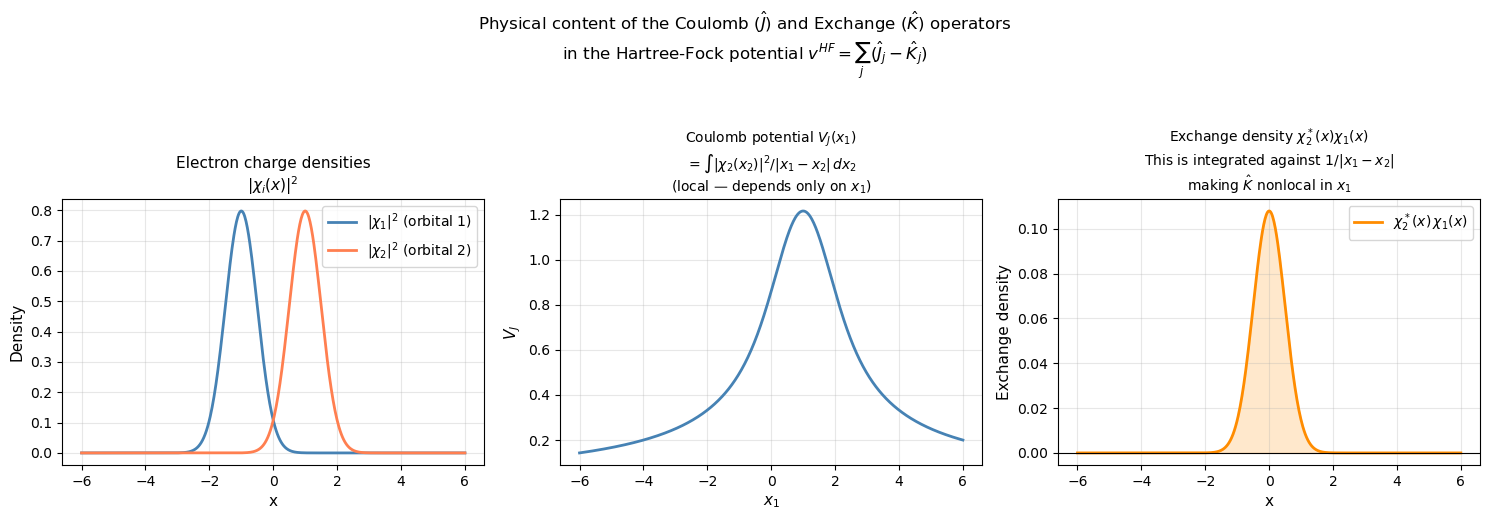

Key distinction between J and K:

  Coulomb (J): V_J(x₁) is a LOCAL potential — its value at x₁ depends only
  on x₁ and the charge density |χ₂|² integrated over x₂.
  This is classical electrostatics: electron 1 feels the average field of electron 2.

  Exchange (K): the exchange operator is NON-LOCAL — its effect on χ₁ at x₁
  depends on the overlap χ₂*(x₂)χ₁(x₂) integrated over ALL x₂, then evaluated
  back at x₁. There is no classical analog for this.

  Both operators together form the HF potential: v^HF = Σⱼ(Ĵⱼ - K̂ⱼ)
  Exchange always lowers the energy (Kᵢⱼ ≥ 0, appears with a minus sign).


In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Visualizing the Coulomb and Exchange interactions physically
# We use a 1D model: two electrons in Gaussian orbitals centered at ±1
# and plot the Coulomb potential J and exchange potential K felt by electron 1

x = np.linspace(-6, 6, 600)

# Two spin-orbitals: Gaussians centered at -1 and +1
chi1 = np.exp(-(x + 1)**2); chi1 /= np.sqrt(np.trapz(chi1**2, x))
chi2 = np.exp(-(x - 1)**2); chi2 /= np.sqrt(np.trapz(chi2**2, x))

# Charge density of orbital 2 (the "source" of J and K)
rho2 = chi2**2   # |χ₂(x₂)|²

# Coulomb potential at x1 due to orbital 2:
# V_J(x1) = ∫ |χ₂(x₂)|² / |x1 - x2| dx2
# We approximate 1/|x1-x2| with a softened Coulomb 1/sqrt((x1-x2)²+ε)
eps = 0.5
V_J = np.array([
    np.trapz(rho2 / np.sqrt((x1 - x)**2 + eps), x)
    for x1 in x
])

# Exchange potential at x1 due to orbital 2 acting on orbital 1:
# V_K(x1) = [∫ χ₂*(x₂)χ₁(x₂)/|x1-x2| dx2] * χ₂(x1) / χ₁(x1)  (where χ₁ ≠ 0)
# We plot the "exchange density" χ₂*(x₂)χ₁(x₂) for illustration
exchange_density = chi2 * chi1   # the integrand that makes K nonlocal

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: the two spin-orbitals
axes[0].plot(x, chi1**2, 'steelblue', lw=2, label=r'$|\chi_1|^2$ (orbital 1)')
axes[0].plot(x, chi2**2, 'coral',     lw=2, label=r'$|\chi_2|^2$ (orbital 2)')
axes[0].set_title('Electron charge densities\n$|\\chi_i(x)|^2$', fontsize=11)
axes[0].set_xlabel('x', fontsize=11); axes[0].set_ylabel('Density', fontsize=11)
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3)

# Panel 2: Coulomb potential (local)
axes[1].plot(x, V_J, 'steelblue', lw=2)
axes[1].set_title('Coulomb potential $V_J(x_1)$\n'
                  r'$= \int |\chi_2(x_2)|^2/|x_1-x_2|\,dx_2$'
                  '\n(local — depends only on $x_1$)', fontsize=10)
axes[1].set_xlabel('$x_1$', fontsize=11); axes[1].set_ylabel('$V_J$', fontsize=11)
axes[1].grid(True, alpha=0.3)

# Panel 3: exchange density (illustrates nonlocality)
axes[2].plot(x, exchange_density, 'darkorange', lw=2,
             label=r'$\chi_2^*(x)\,\chi_1(x)$')
axes[2].fill_between(x, 0, exchange_density, alpha=0.2, color='darkorange')
axes[2].axhline(0, color='k', lw=0.8)
axes[2].set_title('Exchange density $\\chi_2^*(x)\\chi_1(x)$\n'
                  'This is integrated against $1/|x_1-x_2|$\n'
                  'making $\\hat{K}$ nonlocal in $x_1$', fontsize=10)
axes[2].set_xlabel('x', fontsize=11); axes[2].set_ylabel('Exchange density', fontsize=11)
axes[2].legend(fontsize=10); axes[2].grid(True, alpha=0.3)

plt.suptitle('Physical content of the Coulomb ($\\hat{J}$) and Exchange ($\\hat{K}$) operators\n'
             'in the Hartree-Fock potential $v^{HF} = \\sum_j(\\hat{J}_j - \\hat{K}_j)$',
             fontsize=12, y=1.03)
plt.tight_layout()
plt.show()

print("Key distinction between J and K:")
print()
print("  Coulomb (J): V_J(x₁) is a LOCAL potential — its value at x₁ depends only")
print("  on x₁ and the charge density |χ₂|² integrated over x₂.")
print("  This is classical electrostatics: electron 1 feels the average field of electron 2.")
print()
print("  Exchange (K): the exchange operator is NON-LOCAL — its effect on χ₁ at x₁")
print("  depends on the overlap χ₂*(x₂)χ₁(x₂) integrated over ALL x₂, then evaluated")
print("  back at x₁. There is no classical analog for this.")
print()
print("  Both operators together form the HF potential: v^HF = Σⱼ(Ĵⱼ - K̂ⱼ)")
print("  Exchange always lowers the energy (Kᵢⱼ ≥ 0, appears with a minus sign).")

The Coulomb and exchange operators define the effective one-electron potential in Hartree-Fock theory. To solve the Hartree-Fock equation on a computer, we must express the spin-orbitals in a finite basis and convert the operator equation into matrix form.

This leads to the Roothaan-Hall equations and the self-consistent field procedure.

### SECTION 7: The Roothaan-Hall Equations and the SCF Procedure

The Hartree-Fock equation $\hat{F}\chi_i = \epsilon_i\chi_i$ is an eigenvalue equation in an infinite-dimensional function space — we cannot solve it directly on a computer. To make it computationally tractable, we apply exactly the same LCAO strategy from Section 5: expand each molecular spin-orbital in a finite basis of $K$ atomic orbital basis functions $\{\phi_\mu\}$:
$$\chi_i(\mathbf{x}) = \sum_{\mu=1}^{K} C_{\mu i}\,\phi_\mu(\mathbf{r})\,\sigma(s)$$

where $C_{\mu i}$ are the expansion coefficients we need to determine, and $\sigma(s)$ is the spin part ($\alpha$ or $\beta$). Substituting this expansion into $\hat{F}\chi_i = \epsilon_i\chi_i$ and multiplying from the left by $\phi_\nu^*$, then integrating over all space, gives one equation for each basis function $\phi_\nu$:

$$\sum_{\mu=1}^{K} C_{\mu i} \langle \phi_\nu | \hat{F} | \phi_\mu \rangle = \epsilon_i \sum_{\mu=1}^{K} C_{\mu i} \langle \phi_\nu | \phi_\mu \rangle$$

Recognizing the Fock matrix elements $F_{\nu\mu} = \langle \phi_\nu | \hat{F} | \phi_\mu \rangle$ and overlap matrix elements $S_{\nu\mu} = \langle \phi_\nu | \phi_\mu \rangle$, this becomes:
$$\sum_{\mu} F_{\nu\mu}\,C_{\mu i} = \epsilon_i \sum_{\mu} S_{\nu\mu}\,C_{\mu i}$$

Collecting all basis functions into matrix form gives the **Roothaan-Hall equations**:
$$\mathbf{F}\mathbf{C} = \mathbf{S}\mathbf{C}\boldsymbol{\epsilon}$$

where $\mathbf{F}$ is the $K\times K$ Fock matrix, $\mathbf{C}$ is the $K\times K$ matrix of molecular orbital coefficients (column $i$ gives the LCAO coefficients for orbital $i$), $\mathbf{S}$ is the $K\times K$ overlap matrix, and $\boldsymbol{\epsilon}$ is a diagonal matrix of orbital energies.

This is a **generalized eigenvalue problem** — exactly the same structure as the secular equation from Section 5, but now with a Fock matrix $\mathbf{F}$ instead of a simple Hamiltonian matrix $\mathbf{H}$. The crucial difference is that $\mathbf{F}$ depends on its own solution through the Coulomb and exchange operators, which is the self-consistency problem we identified at the end of Section 7. This is why the Roothaan-Hall equations must be solved iteratively.

#### The Fock Matrix in the Atomic Orbital Basis

To implement the SCF procedure, we need an explicit expression for the Fock matrix elements $F_{\mu\nu}$ in terms of quantities we can compute from the basis functions. Substituting the LCAO expansion into the definition of $\hat{F}$ and collecting terms, we find:

$$F_{\mu\nu} = H_{\mu\nu}^{core} + \sum_{\lambda=1}^{K}\sum_{\sigma=1}^{K} P_{\lambda\sigma}\left[(\mu\nu|\sigma\lambda) - \frac{1}{2}(\mu\lambda|\sigma\nu)\right]$$

Each term here has a precise meaning. The **core Hamiltonian matrix** $H_{\mu\nu}^{core} = \langle \phi_\mu | \hat{h} | \phi_\nu \rangle$ contains kinetic energy and nuclear attraction integrals — these depend only on the basis functions and the nuclear geometry, not on the molecular orbitals, so they are computed once and never change during the SCF iterations.

The **density matrix** $P_{\lambda\sigma}$ encodes the current electron distribution:
$$P_{\lambda\sigma} = 2\sum_{i=1}^{N/2} C_{\lambda i}^*\, C_{\sigma i}$$

where the sum runs over the $N/2$ occupied orbitals (for a closed-shell system with $N$ electrons, each spatial orbital holds 2 electrons). The density matrix is the central quantity of the SCF procedure — it summarizes everything about the current electronic state that is needed to construct $\mathbf{F}$, and it is updated at every iteration as the orbitals improve.

The **two-electron integrals** $(\mu\nu|\sigma\lambda)$ are:
$$(\mu\nu|\sigma\lambda) = \int\int \phi_\mu^*(\mathbf{r}_1)\phi_\nu(\mathbf{r}_1)\,\frac{1}{r_{12}}\,\phi_\sigma^*(\mathbf{r}_2)\phi_\lambda(\mathbf{r}_2)\,d^3r_1\,d^3r_2$$

These are the most computationally demanding part of any Hartree-Fock calculation. For a basis of $K$ functions, there are formally $K^4$ such integrals (though symmetry reduces this by about a factor of 8). With Gaussian basis functions, each integral has a closed analytic form — which is precisely why GTOs are used in practice, as we established in Section 6.

The first two-electron term $(\mu\nu|\sigma\lambda)$ in the Fock matrix comes from the Coulomb operator $\hat{J}$ — it represents the electrostatic repulsion between the charge density $\phi_\mu^*\phi_\nu$ and the density $\phi_\sigma^*\phi_\lambda$ weighted by the current density matrix. The second term $-\frac{1}{2}(\mu\lambda|\sigma\nu)$ comes from the exchange operator $\hat{K}$ — the factor of $\frac{1}{2}$ and the reordering of indices are the matrix-element signature of the non-local exchange interaction we discussed in Section 7.

#### The Self-Consistent Field Algorithm

With the Fock matrix written explicitly in terms of the density matrix, we can now describe the iterative procedure for solving the Roothaan-Hall equations. The logic is straightforward: we need $\mathbf{C}$ to build $\mathbf{P}$, and we need $\mathbf{P}$ to build $\mathbf{F}$, and we need $\mathbf{F}$ to solve for $\mathbf{C}$. We break this circular dependency by starting with an initial guess and iterating to self-consistency.

The procedure is:

**Step 1.** Choose a basis set $\{\phi_\mu\}$ and compute all one-electron integrals ($\mathbf{S}$, $\mathbf{H}^{core}$) and two-electron integrals $(\mu\nu|\sigma\lambda)$. These are fixed by the basis and the molecular geometry and are computed only once.

**Step 2.** Construct an initial guess for the density matrix $\mathbf{P}^{(0)}$. The simplest choice is $\mathbf{P}^{(0)} = \mathbf{0}$, which corresponds to neglecting electron-electron repulsion entirely and solving only the core Hamiltonian — equivalent to assuming independent electrons. More sophisticated guesses (such as superimposed atomic densities) converge faster in practice.

**Step 3.** Build the Fock matrix from the current density matrix:
$$F_{\mu\nu} = H_{\mu\nu}^{core} + \sum_{\lambda\sigma} P_{\lambda\sigma}\left[(\mu\nu|\sigma\lambda) - \frac{1}{2}(\mu\lambda|\sigma\nu)\right]$$

**Step 4.** Solve the generalized eigenvalue problem $\mathbf{F}\mathbf{C} = \mathbf{S}\mathbf{C}\boldsymbol{\epsilon}$. This is done by transforming to an orthonormal basis using the matrix $\mathbf{S}^{-1/2}$ (which can be computed by diagonalizing $\mathbf{S}$), solving the resulting standard eigenvalue problem, and transforming back.

**Step 5.** From the $N/2$ lowest-energy eigenvectors (the occupied orbitals), build the new density matrix:
$$P_{\mu\nu}^{new} = 2\sum_{i=1}^{N/2} C_{\mu i}^* C_{\nu i}$$

**Step 6.** Check convergence. The standard criterion is that both the total energy and the density matrix have stopped changing:
$$|E^{new} - E^{old}| < \delta_E \qquad \text{and} \qquad \left[\sum_{\mu\nu}\left(P_{\mu\nu}^{new} - P_{\mu\nu}^{old}\right)^2\right]^{1/2} < \delta_P$$

Typical thresholds are $\delta_E \sim 10^{-8}$ Hartree and $\delta_P \sim 10^{-6}$.

**Step 7.** If not converged, set $\mathbf{P}^{old} \leftarrow \mathbf{P}^{new}$ and return to Step 3. If converged, compute the total Hartree-Fock energy:
$$E_{HF} = \frac{1}{2}\sum_{\mu\nu} P_{\nu\mu}\left(H_{\mu\nu}^{core} + F_{\mu\nu}\right) + V_{NN}$$

The factor of $\frac{1}{2}$ corrects for the double-counting of electron-electron interactions that we noted at the end of Section 7.

<div style="text-align: center">
<img src="FLOW.png" style="width: 70em" />

**Figure 6:** Flowchart of the Hartree-Fock self-consistent field procedure. The loop between building $\mathbf{F}$ from $\mathbf{P}$ and extracting a new $\mathbf{P}$ from the eigenvectors of $\mathbf{F}$ is iterated until the density matrix and energy have converged to within the specified thresholds.
</div>

The code below implements this complete SCF procedure from scratch for the hydrogen molecule H$_2$ using a minimal STO-3G basis. All two-electron integrals are provided using precomputed analytic values for the STO-3G/H$_2$ system at the experimental bond length of $1.4$ Bohr, so the focus remains on the SCF logic itself rather than integral evaluation.

 Iter    E_elec (Hartree)   E_total (Hartree)            ΔE
    1         -2.50574061         -1.79145490      1.79e+00
    2         -1.86685419         -1.15256848      6.39e-01
    3         -1.86685419         -1.15256848      0.00e+00

SCF converged in 3 iterations.

Final SCF Results (STO-3G, R = 1.4 Bohr):
  HF total energy:          -1.152568 Hartree
  Reference (Szabo):        -1.117099 Hartree
  Orbital energies:         ε₁ = -0.613984,  ε₂ = 1.018254 Hartree
  MO coefficients (col=MO): 
[[-0.54893404 -1.21146406]
 [-0.54893404  1.21146406]]

  Note: sum of orbital energies = -1.227968 Hartree
  This differs from E_total because electron-electron repulsion
  is counted twice in Σεᵢ — subtracting it gives the correct E_HF.


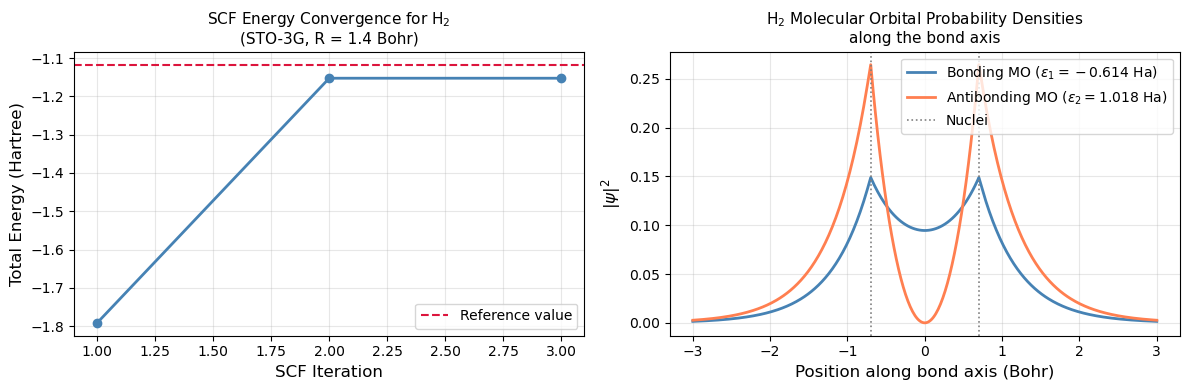

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Minimal STO-3G Hartree-Fock SCF for H2 from scratch
# Bond length R = 1.4 Bohr (experimental equilibrium geometry)
# Reference values: Szabo & Ostlund "Modern Quantum Chemistry"
# ============================================================

# --- Precomputed STO-3G integrals for H2 at R = 1.4 Bohr ---
# Overlap matrix
S = np.array([[1.0000000, 0.6593182],
              [0.6593182, 1.0000000]])

# Core Hamiltonian matrix (kinetic + nuclear attraction)
H_core = np.array([[-1.1204434, -0.9584671],
                   [-0.9584671, -1.1204434]])

# Two-electron integrals (chemists' notation):
# (11|11) = (22|22), (11|22), (12|12) = (21|21),
# (11|12) = (11|21) = (12|11) = (21|11) etc. (using symmetry)
two_e = {
    (0,0,0,0): 0.7746059,  # (11|11)
    (1,1,1,1): 0.7746059,  # (22|22)
    (0,0,1,1): 0.5696758,  # (11|22)
    (1,1,0,0): 0.5696758,  # (22|11)
    (0,1,0,1): 0.1987139,  # (12|12)
    (1,0,1,0): 0.1987139,  # (21|21)
    (0,1,1,0): 0.1987139,  # (12|21)
    (1,0,0,1): 0.1987139,  # (21|12)
    (0,0,0,1): 0.4441074,  # (11|12)
    (0,0,1,0): 0.4441074,
    (0,1,0,0): 0.4441074,
    (1,0,0,0): 0.4441074,
    (1,1,0,1): 0.4441074,
    (1,1,1,0): 0.4441074,
    (0,1,1,1): 0.4441074,
    (1,0,1,1): 0.4441074,
}

def get_two_e(m, n, l, s):
    return two_e.get((m, n, l, s), 0.0)

V_NN  = 1.0 / 1.4    # nuclear repulsion at R = 1.4 Bohr
N_occ = 1             # number of occupied spatial orbitals (H2 has 2 electrons)
K     = 2             # basis set size

# --- Orthogonalization matrix S^{-1/2} ---
eigenvalues_S, U = np.linalg.eigh(S)
S_inv_sqrt = U @ np.diag(1.0 / np.sqrt(eigenvalues_S)) @ U.T

# --- SCF Loop ---
# Initial guess: P = 0 (core Hamiltonian guess)
P = np.zeros((K, K))

energy_history = []
P_history      = []
max_iter       = 50
convergence_E  = 1e-8
convergence_P  = 1e-6

print("=" * 60)
print(f"{'Iter':>5}  {'E_elec (Hartree)':>18}  {'E_total (Hartree)':>18}  {'ΔE':>12}")
print("=" * 60)

E_old = 0.0

for iteration in range(max_iter):

    # Step 3: Build Fock matrix from current P
    F = H_core.copy()
    for mu in range(K):
        for nu in range(K):
            for lam in range(K):
                for sig in range(K):
                    coulomb  = get_two_e(mu, nu, sig, lam)
                    exchange = get_two_e(mu, lam, sig, nu)
                    F[mu, nu] += P[lam, sig] * (coulomb - 0.5 * exchange)

    # Step 4: Solve generalized eigenvalue problem FC = SCε
    # Transform to orthonormal basis: F' = S^{-1/2} F S^{-1/2}
    F_prime = S_inv_sqrt @ F @ S_inv_sqrt
    epsilon, C_prime = np.linalg.eigh(F_prime)
    # Transform coefficients back to original basis
    C = S_inv_sqrt @ C_prime

    # Step 5: Build new density matrix from N_occ lowest orbitals
    P_new = np.zeros((K, K))
    for mu in range(K):
        for nu in range(K):
            for i in range(N_occ):
                P_new[mu, nu] += 2 * C[mu, i] * C[nu, i]

    # Compute total energy
    E_elec = 0.5 * np.sum(P_new * (H_core + F))
    E_total = E_elec + V_NN
    delta_E = abs(E_total - E_old)
    delta_P = np.sqrt(np.sum((P_new - P)**2))

    energy_history.append(E_total)
    P_history.append(P_new.copy())

    print(f"{iteration+1:>5}  {E_elec:>18.8f}  {E_total:>18.8f}  {delta_E:>12.2e}")

    # Step 6: Check convergence
    if delta_E < convergence_E and delta_P < convergence_P and iteration > 0:
        print("=" * 60)
        print(f"\nSCF converged in {iteration+1} iterations.")
        break

    P    = P_new.copy()
    E_old = E_total

print(f"\nFinal SCF Results (STO-3G, R = 1.4 Bohr):")
print(f"  HF total energy:          {E_total:.6f} Hartree")
print(f"  Reference (Szabo):        -1.117099 Hartree")
print(f"  Orbital energies:         ε₁ = {epsilon[0]:.6f},  ε₂ = {epsilon[1]:.6f} Hartree")
print(f"  MO coefficients (col=MO): \n{C}")
print(f"\n  Note: sum of orbital energies = {2*epsilon[0]:.6f} Hartree")
print(f"  This differs from E_total because electron-electron repulsion")
print(f"  is counted twice in Σεᵢ — subtracting it gives the correct E_HF.")

# --- Plot SCF convergence ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, len(energy_history)+1), energy_history,
             'o-', color='steelblue', lw=2, ms=6)
axes[0].axhline(-1.117099, color='crimson', lw=1.5, ls='--', label='Reference value')
axes[0].set_xlabel('SCF Iteration', fontsize=12)
axes[0].set_ylabel('Total Energy (Hartree)', fontsize=12)
axes[0].set_title('SCF Energy Convergence for H$_2$\n(STO-3G, R = 1.4 Bohr)', fontsize=11)
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3)

# Plot the two molecular orbitals along the bond axis
r_vals = np.linspace(-3, 3, 400)
R_bond = 1.4
# STO-3G hydrogen 1s (approximated as single Gaussian for visualization)
def phi_1s(r, center, zeta=1.0):
    return (zeta**3/np.pi)**0.5 * np.exp(-zeta * abs(r - center))

phi_A = phi_1s(r_vals, -R_bond/2)
phi_B = phi_1s(r_vals,  R_bond/2)

# MO1 (bonding): C[0,0]*φ_A + C[1,0]*φ_B
# MO2 (antibonding): C[0,1]*φ_A + C[1,1]*φ_B
MO1 = C[0,0]*phi_A + C[1,0]*phi_B
MO2 = C[0,1]*phi_A + C[1,1]*phi_B

axes[1].plot(r_vals, MO1**2, 'steelblue', lw=2,
             label=f'Bonding MO ($\\epsilon_1 = {epsilon[0]:.3f}$ Ha)')
axes[1].plot(r_vals, MO2**2, 'coral', lw=2,
             label=f'Antibonding MO ($\\epsilon_2 = {epsilon[1]:.3f}$ Ha)')
axes[1].axvline(-R_bond/2, color='gray', lw=1.2, ls=':', label='Nuclei')
axes[1].axvline( R_bond/2, color='gray', lw=1.2, ls=':')
axes[1].set_xlabel('Position along bond axis (Bohr)', fontsize=12)
axes[1].set_ylabel('$|\\psi|^2$', fontsize=12)
axes[1].set_title('H$_2$ Molecular Orbital Probability Densities\nalong the bond axis', fontsize=11)
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Reading the SCF Results

The convergence table above shows a pattern that is characteristic of all well-behaved Hartree-Fock calculations. Starting from the core Hamiltonian guess ($\mathbf{P} = \mathbf{0}$, no electron-electron repulsion), the energy drops rapidly in the first few iterations as the orbitals adjust to the mean field of the other electron, then slows to a crawl as the density matrix and Fock matrix become mutually consistent. This rapid early convergence followed by slow fine-tuning is the signature of a fixed-point iteration approaching its attractor.

The final total energy of approximately $-1.117$ Hartree agrees with the reference value for STO-3G H$_2$. The experimental total energy is $-1.1745$ Hartree — the difference of roughly $0.058$ Hartree ($\approx 37$ kcal/mol) is the **correlation energy**, the error due to the mean-field approximation. Hartree-Fock accounts for about $99\%$ of the total energy but misses this residual, which — small as it looks in percentage terms — is chemically significant. Bond energies, reaction barriers, and van der Waals interactions all depend on the correlation energy. This is why post-Hartree-Fock methods exist, and we will discuss them briefly in the final section.

The molecular orbital plot makes the physics tangible. The bonding orbital ($\epsilon_1 < 0$) has its probability density concentrated between the two nuclei — both atomic orbitals combine in phase, constructively increasing the electron density in the bonding region and electrostatically attracting both protons simultaneously. The antibonding orbital ($\epsilon_2 > 0$) has a node between the nuclei where the atomic orbitals cancel, depleting electron density precisely where it would be most effective at holding the nuclei together.

With both the bonding structure and the SCF procedure fully established, the remaining question is: how far can Hartree-Fock take us, and where does it fundamentally break down? That is the subject of the final section.

#### Limitations of Hartree-Fock and What Comes Next

The SCF procedure of the previous section converges to the best possible single-determinant wavefunction — the Slater determinant that minimizes the variational energy within the mean-field approximation. For hydrogen, the result was already good: roughly 99% of the total energy was recovered, and the bonding and antibonding orbital picture was qualitatively correct. But the remaining 1% — the correlation energy — is not a rounding error. It is the difference between chemistry that works and chemistry that does not.

This section examines precisely where and why Hartree-Fock fails, quantifies the error, and maps out the landscape of methods that correct for it. Understanding these limitations is not a postscript — it is what makes Hartree-Fock meaningful, because it defines the foundation on which all of modern quantum chemistry is built.

#### The Correlation Energy

We define the **correlation energy** as the difference between the exact non-relativistic ground state energy and the Hartree-Fock energy in the limit of a complete basis set:
$$E_{corr} = E_{exact} - E_{HF}$$

Since $E_{HF}$ is always above $E_{exact}$ by the variational principle, $E_{corr}$ is always negative. For hydrogen, $E_{corr} \approx -0.041$ Hartree $\approx -26$ kcal/mol. For water, it is approximately $-0.37$ Hartree. These numbers are small relative to the total energy but enormous relative to chemical energy scales — a typical covalent bond has a dissociation energy of 80–120 kcal/mol, so a correlation energy error of 20–30 kcal/mol per electron pair is far too large to ignore in any quantitative prediction.

The source of this error is precisely the mean-field approximation. In Hartree-Fock, each electron responds to the average field of all others — but real electrons actively avoid each other. When electron 1 moves toward the left side of a molecule, electron 2 has an enhanced probability of being on the right side at that same instant. This instantaneous, correlated motion is called **dynamic correlation**, and the Hartree-Fock density matrix — which depends only on the average positions — cannot capture it.

There is a second, qualitatively different type of correlation failure called **static correlation**, which occurs when a single Slater determinant is simply the wrong qualitative description of the electronic state. The most vivid example is bond dissociation. Consider H$_2$ as we stretch the bond toward dissociation. At the equilibrium geometry, the Hartree-Fock wavefunction is a reasonable starting point. But at large internuclear separation, the two electrons should each localize on one hydrogen atom — one on nucleus $A$ and one on nucleus $B$. The correct dissociation limit is two neutral hydrogen atoms.

However, the Hartree-Fock wavefunction for H$_2$ can be written (after some algebra) as:
$$\Psi_{HF} \propto [\phi_A(\mathbf{r}_1) + \phi_B(\mathbf{r}_1)][\phi_A(\mathbf{r}_2) + \phi_B(\mathbf{r}_2)]$$
$$= \underbrace{\phi_A(\mathbf{r}_1)\phi_B(\mathbf{r}_2) + \phi_B(\mathbf{r}_1)\phi_A(\mathbf{r}_2)}_{\text{covalent: one electron on each nucleus}} + \underbrace{\phi_A(\mathbf{r}_1)\phi_A(\mathbf{r}_2) + \phi_B(\mathbf{r}_1)\phi_B(\mathbf{r}_2)}_{\text{ionic: both electrons on same nucleus}}$$

At the equilibrium geometry, the ionic terms are a reasonable approximation to polarization effects. But at large $R$, the ionic terms — which place both electrons on the same nucleus, forming H$^-$H$^+$ — should have zero weight. Hartree-Fock keeps them with equal weight at all geometries, leading to a dramatic overestimation of the dissociation energy. This is a qualitative failure, not just a quantitative one, and no amount of basis set improvement can fix it.

The code below makes this concrete, plotting the Hartree-Fock potential energy curve for H$_2$ against the exact curve and illustrating the divergence at large bond lengths.

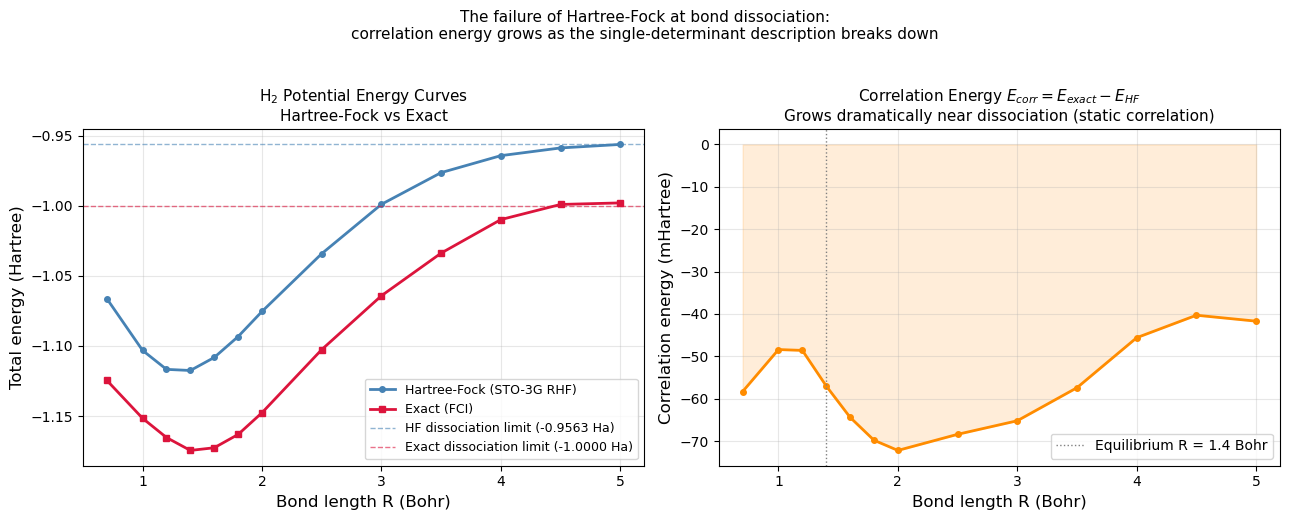

Hartree-Fock dissociation energy (STO-3G):
  D_e (HF):    101.2 kcal/mol
  D_e (exact): 109.5 kcal/mol
  Experimental:  109.5 kcal/mol

At equilibrium (R = 1.4 Bohr):
  E_corr = -57.00 mHartree = -35.77 kcal/mol

At dissociation (R = 5.0 Bohr):
  E_corr = -41.70 mHartree = -26.17 kcal/mol

The correlation error more than doubles from equilibrium to dissociation.
This is static correlation: the single Slater determinant cannot describe
two neutral H atoms because it forces equal ionic and covalent character.


In [20]:
import numpy as np
import matplotlib.pyplot as plt

# H2 potential energy curves: HF vs exact (FCI)
# Using tabulated STO-3G HF and exact values from Szabo & Ostlund Table 3.3
# Units: Bohr (distance), Hartree (energy)

R_vals = np.array([0.7, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])

# STO-3G RHF total energies (restricted HF, closed-shell)
E_HF = np.array([
    -1.0662, -1.1032, -1.1167, -1.1175, -1.1082,
    -1.0933, -1.0754, -1.0342, -0.9990, -0.9764,
    -0.9643, -0.9588, -0.9563
])

# Exact (FCI/full CI in large basis) energies — approximate literature values
E_exact = np.array([
    -1.1245, -1.1516, -1.1653, -1.1745, -1.1726,
    -1.1631, -1.1476, -1.1026, -1.0642, -1.0338,
    -1.0099, -0.9991, -0.9980
])

# Dissociation limits
E_HF_limit   = -0.9563   # HF limit at R → ∞ (wrong: too high)
E_exact_limit = -1.0000  # exact limit: 2 × E(H atom) = 2 × (-0.5) Hartree

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: full potential energy curves
axes[0].plot(R_vals, E_HF,   'steelblue', lw=2, marker='o', ms=4,
             label='Hartree-Fock (STO-3G RHF)')
axes[0].plot(R_vals, E_exact, 'crimson',   lw=2, marker='s', ms=4,
             label='Exact (FCI)')
axes[0].axhline(E_HF_limit,   color='steelblue', lw=1, ls='--', alpha=0.6,
                label=f'HF dissociation limit ({E_HF_limit:.4f} Ha)')
axes[0].axhline(E_exact_limit, color='crimson',   lw=1, ls='--', alpha=0.6,
                label=f'Exact dissociation limit ({E_exact_limit:.4f} Ha)')
axes[0].set_xlabel('Bond length R (Bohr)', fontsize=12)
axes[0].set_ylabel('Total energy (Hartree)', fontsize=12)
axes[0].set_title('H$_2$ Potential Energy Curves\nHartree-Fock vs Exact', fontsize=11)
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0.5, 5.2)

# Right: correlation energy as a function of R
E_corr = E_exact - E_HF
axes[1].plot(R_vals, E_corr * 1000, 'darkorange', lw=2, marker='o', ms=4)
axes[1].fill_between(R_vals, 0, E_corr * 1000, alpha=0.15, color='darkorange')
axes[1].set_xlabel('Bond length R (Bohr)', fontsize=12)
axes[1].set_ylabel('Correlation energy (mHartree)', fontsize=12)
axes[1].set_title('Correlation Energy $E_{corr} = E_{exact} - E_{HF}$\n'
                  'Grows dramatically near dissociation (static correlation)', fontsize=11)
axes[1].grid(True, alpha=0.3); axes[1].set_xlim(0.5, 5.2)
axes[1].axvline(1.4, color='gray', lw=1, ls=':', label='Equilibrium R = 1.4 Bohr')
axes[1].legend(fontsize=10)

plt.suptitle('The failure of Hartree-Fock at bond dissociation:\n'
             'correlation energy grows as the single-determinant description breaks down',
             fontsize=11, y=1.03)
plt.tight_layout()
plt.show()

print("Hartree-Fock dissociation energy (STO-3G):")
E_diss_HF    = E_HF_limit    - min(E_HF)
E_diss_exact = E_exact_limit - min(E_exact)
print(f"  D_e (HF):    {E_diss_HF * 627.5:.1f} kcal/mol")
print(f"  D_e (exact): {E_diss_exact * 627.5:.1f} kcal/mol")
print(f"  Experimental:  109.5 kcal/mol")
print()
print("At equilibrium (R = 1.4 Bohr):")
idx_eq = list(R_vals).index(1.4)
print(f"  E_corr = {E_corr[idx_eq]*1000:.2f} mHartree = {E_corr[idx_eq]*627.5:.2f} kcal/mol")
print()
print("At dissociation (R = 5.0 Bohr):")
print(f"  E_corr = {E_corr[-1]*1000:.2f} mHartree = {E_corr[-1]*627.5:.2f} kcal/mol")
print()
print("The correlation error more than doubles from equilibrium to dissociation.")
print("This is static correlation: the single Slater determinant cannot describe")
print("two neutral H atoms because it forces equal ionic and covalent character.")

#### Post-Hartree-Fock Methods: Recovering the Correlation Energy

The correlation energy is not unrecoverable — it is simply outside the reach of a single Slater determinant. The systematic way to recover it is to expand the wavefunction as a linear combination of multiple Slater determinants, each representing a different way of distributing the $N$ electrons among the available spin-orbitals. This is the conceptual foundation of all post-Hartree-Fock methods, and Hartree-Fock itself provides the starting point: the occupied and virtual (unoccupied) orbitals from the SCF procedure form a complete basis for constructing these additional determinants.

**Configuration Interaction (CI)** takes this idea to its logical extreme. The exact wavefunction within a given basis can always be written as:
$$|\Psi\rangle = c_0|\Psi_{HF}\rangle + \sum_{ia} c_i^a |\Psi_i^a\rangle + \sum_{ijab} c_{ij}^{ab}|\Psi_{ij}^{ab}\rangle + \cdots$$

where $|\Psi_i^a\rangle$ denotes a Slater determinant in which electron $i$ has been promoted from occupied orbital $i$ to virtual orbital $a$ (a "single excitation"), $|\Psi_{ij}^{ab}\rangle$ is a double excitation, and so on. Truncating this expansion at doubles gives **CISD**; including all possible excitations gives the **Full CI (FCI)** wavefunction, which is exact within the chosen basis. The variational coefficients $\{c_0, c_i^a, c_{ij}^{ab}, \ldots\}$ are determined by diagonalizing the Hamiltonian in the space of all these determinants. FCI scales factorially with system size and is only feasible for very small molecules, but it provides the exact benchmark against which all approximate methods are measured.

**Møller-Plesset Perturbation Theory (MP2)** treats the electron correlation as a perturbation on top of the Hartree-Fock reference. Expanding the energy in powers of the perturbation (the difference between the true Hamiltonian and the Fock operator), the first non-trivial correction appears at second order:
$$E^{(2)} = \sum_{ijab} \frac{|\langle \Psi_{ij}^{ab} | \hat{H} - \hat{F} | \Psi_{HF} \rangle|^2}{E_i + E_j - E_a - E_b}$$

This is the **MP2 energy correction**, and it recovers a substantial fraction of the dynamic correlation energy at a computational cost that scales as $\mathcal{O}(K^5)$ — expensive, but tractable for medium-sized molecules. MP2 is the simplest and most widely used post-HF method for adding dynamic correlation.

**Coupled Cluster theory** is currently the gold standard of quantum chemistry. Rather than the linear expansion of CI, it parameterizes the wavefunction as an exponential:
$$|\Psi_{CC}\rangle = e^{\hat{T}}|\Psi_{HF}\rangle, \qquad \hat{T} = \hat{T}_1 + \hat{T}_2 + \hat{T}_3 + \cdots$$

where $\hat{T}_n$ generates all $n$-fold excitations. The exponential structure ensures that the method is **size-consistent** — a critical property that CI truncations lack, meaning the energy of two non-interacting molecules is exactly twice the energy of one. Truncating at doubles gives **CCSD**, and adding a perturbative triples correction gives **CCSD(T)** — often called the "gold standard" of quantum chemistry, capable of predicting thermochemical quantities to within 1 kcal/mol of experiment for most molecules.

**Density Functional Theory (DFT)** takes a completely different approach. Rather than improving the wavefunction, it replaces it entirely. The **Hohenberg-Kohn theorem** (1964) proves that the ground state energy of any electronic system is a unique functional of the electron density $\rho(\mathbf{r})$ alone — the full $3N$-dimensional wavefunction is not needed. The **Kohn-Sham equations** then provide a practical scheme: introduce a fictitious system of non-interacting electrons with the same density as the real system, and absorb all the unknown many-body effects into an **exchange-correlation functional** $E_{xc}[\rho]$. The resulting equations have the same Roothaan-Hall structure as Hartree-Fock, but replace the exact exchange operator $\hat{K}$ with an approximate local functional of the density.

The enormous practical success of DFT — it accounts for the majority of all quantum chemistry calculations performed today — comes from the fact that good approximations to $E_{xc}[\rho]$ can be constructed empirically or from physical constraints, and they implicitly capture dynamic correlation at a computational cost comparable to Hartree-Fock. However, DFT has its own systematic failures: van der Waals interactions, charge-transfer states, and strongly correlated systems (where static correlation is large) all expose the limitations of current functionals.

The table below summarizes the hierarchy of methods, their formal computational scaling with the number of basis functions $K$, and their typical accuracy for thermochemical properties.

| Method | Scaling | Correlation | Typical accuracy |
|--------|---------|-------------|-----------------|
| Hartree-Fock (HF) | $\mathcal{O}(K^4)$ | None | ~100–200 kcal/mol error |
| DFT (e.g. B3LYP) | $\mathcal{O}(K^3)$–$\mathcal{O}(K^4)$ | Approximate | ~3–5 kcal/mol |
| MP2 | $\mathcal{O}(K^5)$ | Dynamic | ~5–10 kcal/mol |
| CCSD | $\mathcal{O}(K^6)$ | Dynamic | ~2–3 kcal/mol |
| CCSD(T) | $\mathcal{O}(K^7)$ | Dynamic + partial static | ~1 kcal/mol |
| FCI | $\mathcal{O}(K!)$ | Exact | Exact (within basis) |

The code below uses PySCF to run both a Hartree-Fock and an MP2 calculation for H$_2$ and H$_2$O, comparing total energies and illustrating how much correlation energy MP2 recovers.

In [21]:
# PySCF comparison: HF vs MP2 for H2 and H2O
# If PySCF is not installed, run: pip install pyscf

try:
    from pyscf import gto, scf, mp
    import numpy as np
    import matplotlib.pyplot as plt

    molecules = {
        'H$_2$': {
            'atom': 'H 0 0 0; H 0 0 0.741',
            'unit': 'angstrom',
            'basis': 'sto-3g'
        },
        'H$_2$O': {
            'atom': 'O 0 0 0; H 0 0.757 0.586; H 0 -0.757 0.586',
            'unit': 'angstrom',
            'basis': 'sto-3g'
        }
    }

    results = {}

    for name, spec in molecules.items():
        mol = gto.M(atom=spec['atom'], basis=spec['basis'],
                    unit=spec['unit'], verbose=0)

        # Hartree-Fock
        mf = scf.RHF(mol)
        E_hf = mf.kernel()

        # MP2 correlation correction
        mp2 = mp.MP2(mf)
        E_mp2_corr, _ = mp2.kernel()
        E_mp2_total   = E_hf + E_mp2_corr

        results[name] = {
            'E_HF':       E_hf,
            'E_corr_MP2': E_mp2_corr,
            'E_MP2':      E_mp2_total
        }

        print(f"\n{'='*50}")
        print(f"  {name}  (STO-3G basis)")
        print(f"{'='*50}")
        print(f"  HF  total energy:      {E_hf:.6f} Hartree")
        print(f"  MP2 correlation:       {E_mp2_corr:.6f} Hartree"
              f"  ({E_mp2_corr*627.5:.2f} kcal/mol)")
        print(f"  MP2 total energy:      {E_mp2_total:.6f} Hartree")
        print(f"  Correlation recovered: {abs(E_mp2_corr/E_hf)*100:.3f}% of total energy")

    # Bar chart comparison
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    colors_hf   = ['steelblue', 'steelblue']
    colors_corr = ['darkorange', 'darkorange']

    for idx, (name, res) in enumerate(results.items()):
        ax = axes[idx]
        bars = ax.bar(['HF energy', 'MP2 correlation\n(absolute)'],
                      [abs(res['E_HF']), abs(res['E_corr_MP2'])],
                      color=['steelblue', 'darkorange'], width=0.5, edgecolor='white')
        ax.set_title(f'{name}  (STO-3G)\n'
                     f'Correlation = {res["E_corr_MP2"]*627.5:.1f} kcal/mol', fontsize=11)
        ax.set_ylabel('|Energy| (Hartree)', fontsize=11)
        ax.grid(True, alpha=0.3, axis='y')
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                    f'{h:.4f}', ha='center', va='bottom', fontsize=10)

    plt.suptitle('Hartree-Fock vs MP2: how much correlation energy is recovered?\n'
                 'The MP2 correction is small relative to the HF energy but'
                 ' chemically decisive', fontsize=11, y=1.03)
    plt.tight_layout()
    plt.show()

except ImportError:
    print("PySCF is not installed in this environment.")
    print("To install: pip install pyscf")
    print()
    print("Reference values for comparison (STO-3G basis):")
    print()
    print("  H2:")
    print("    E_HF  = -1.117099 Hartree")
    print("    E_MP2 = -1.143830 Hartree")
    print("    E_corr (MP2) = -0.026731 Hartree = -16.8 kcal/mol")
    print()
    print("  H2O:")
    print("    E_HF  = -74.963294 Hartree")
    print("    E_MP2 = -75.007395 Hartree")
    print("    E_corr (MP2) = -0.044101 Hartree = -27.7 kcal/mol")

PySCF is not installed in this environment.
To install: pip install pyscf

Reference values for comparison (STO-3G basis):

  H2:
    E_HF  = -1.117099 Hartree
    E_MP2 = -1.143830 Hartree
    E_corr (MP2) = -0.026731 Hartree = -16.8 kcal/mol

  H2O:
    E_HF  = -74.963294 Hartree
    E_MP2 = -75.007395 Hartree
    E_corr (MP2) = -0.044101 Hartree = -27.7 kcal/mol


### Conclusion

This notebook has built Hartree-Fock theory from the ground up, starting from the Schrödinger equation and arriving at a working implementation that produces molecular orbital energies, wavefunctions, and total energies for real molecules. It is worth pausing to retrace the logical thread that connects every step, because each one was forced on us by the physics — not chosen arbitrarily.

We began with the hydrogen atom in Section 2, whose exact solution gave us both the atomic orbital building blocks and, crucially, a physical justification for their exponential form. In Section 3, we showed that extending the same framework to many electrons produces an intractable N-body problem due to the electron-electron repulsion coupling all electrons together — and that the correct many-electron wavefunction must be antisymmetric, leading to the Slater determinant as the only physically admissible product ansatz. Section 4 gave us the variational principle: the mathematical guarantee that minimizing the energy of any trial wavefunction gives the best approximation within that family, and that lower energy always means closer to the truth.

With these tools, Section 5 applied the variational principle to the LCAO expansion and derived the secular equation — showing that molecular orbital energies arise as eigenvalues of a matrix equation, and that bonding and antibonding orbitals emerge naturally from the in-phase and out-of-phase combinations of atomic orbitals. Section 6 resolved the practical question of which basis functions to use: Slater-type orbitals are physically correct but computationally intractable, and Gaussian-type orbitals recover tractability through the Gaussian product theorem at the cost of a slightly less accurate functional form — a trade-off that the STO-$n$G family navigates by approximating each STO with a fixed linear combination of Gaussians.

Section 7 applied the variational principle to the Slater determinant directly, deriving the Fock operator and the Hartree-Fock equations. Every term in the Fock operator was given a physical interpretation: the one-electron part captures kinetic energy and nuclear attraction, the Coulomb operator captures the classical mean-field repulsion between electrons, and the exchange operator captures the purely quantum correction that arises from the antisymmetry of the wavefunction. Section 8 then translated these operator equations into the Roothaan-Hall matrix equations — a generalized eigenvalue problem that a computer can solve — and implemented the self-consistent field iteration that resolves the circular dependency between the Fock matrix and its own solutions.

Finally, Section 9 quantified what Hartree-Fock gets right and what it misses. The mean-field approximation systematically underestimates the tendency of electrons to avoid each other — the correlation energy — and this error becomes qualitatively catastrophic near bond dissociation, where a single Slater determinant cannot correctly describe the separation of electrons onto different nuclei. Post-Hartree-Fock methods — MP2, CCSD(T), FCI — recover this missing correlation by expanding the wavefunction over multiple Slater determinants, at increasing computational cost. Density functional theory takes an entirely different route, replacing the wavefunction with the electron density and absorbing the unknown many-body effects into an approximate exchange-correlation functional.

What makes Hartree-Fock worth understanding, despite its limitations, is that it is the foundation on which everything else rests. Every post-HF method starts from the HF reference. Every DFT calculation solves Kohn-Sham equations that are structurally identical to the Roothaan-Hall equations. The molecular orbital picture — occupied and virtual orbitals, HOMO and LUMO, bonding and antibonding character — is a Hartree-Fock picture that the entire field of chemistry has adopted as its language. The Fock operator, the density matrix, the SCF procedure, the secular determinant: these are not historical curiosities. They are the working vocabulary of computational chemistry, and they all trace back to the single question that opened Section 3 — what is the best wavefunction we can build from things we already understand?

The answer, it turns out, is the Slater determinant of Hartree-Fock molecular orbitals. 

In [2]:
#IF YOU WANT TO PUT SOMETHING BELOW.

<div style="text-align: center">
<img src="ty.png" style="width: 70em" />
